# SRN: 220457675
# ST3189 Machine Learning Coursework

## Datasets:

### Body Fat Prediction: https://www.kaggle.com/datasets/fedesoriano/body-fat-prediction-dataset
### Heart Failure Clinical Records: https://archive.ics.uci.edu/dataset/519/heart+failure+clinical+records

## Importing Libraries

In [1]:
import os                                            ## Used to get working directory
import pandas as pd                                  ## Used for data manipulation and analysis
import numpy as np                                   ## Used for working with arrays
import matplotlib.pyplot as plt                      ## Used for data visualisations
import seaborn as sns                                ## Data visualisation library based on matplotlib
from sklearn.preprocessing import StandardScaler                      ## Used for scaling
from sklearn.decomposition import PCA                                 ## Principal Component Analysis
from sklearn.cluster import KMeans, AgglomerativeClustering           ## Used for clustering
from scipy.cluster.hierarchy import dendrogram, linkage               ## Hierarchical Clustering
from sklearn.model_selection import train_test_split, GridSearchCV    ## Used to split data, and for hyperparameter tuning
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression         ## Regression and Classification models
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier                  ## Regression and Classification models
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier                      ## Regression and Classification models
from sklearn.neighbors import KNeighborsClassifier                                          ## Classification model 
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, balanced_accuracy_score, f1_score, confusion_matrix     ## Performance Metrics

## Loading both datasets

In [2]:
## Ensuring that both datasets and notebook are in the same directory
# print(os.getcwd())                    

In [3]:
## Loading both datasets
data_bf = pd.read_csv("bodyfat.csv")
data_hfcr = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [4]:
## Showing Body Fat Prediction
data_bf.head()    

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [5]:
## Showing Heart Failure Clinical Records
data_hfcr.head()    

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## Data Exploration and Cleaning

### Body Fat Dataset

In [6]:
## Checking for duplicated values
data_bf.duplicated().sum()

0

In [7]:
## Checking for NA values
data_bf.isna().sum()

Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

No duplicates and missing values

In [8]:
## Summary Statistics
data_bf.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


From the above summary statistics, it indicates a minimum body fat percentage of 0%, which is not biologically plausible. Thus, it will be excluded from further analysis.

In [9]:
## Removing the row with 0% body fat
data_bf = data_bf[data_bf['BodyFat']!= 0]

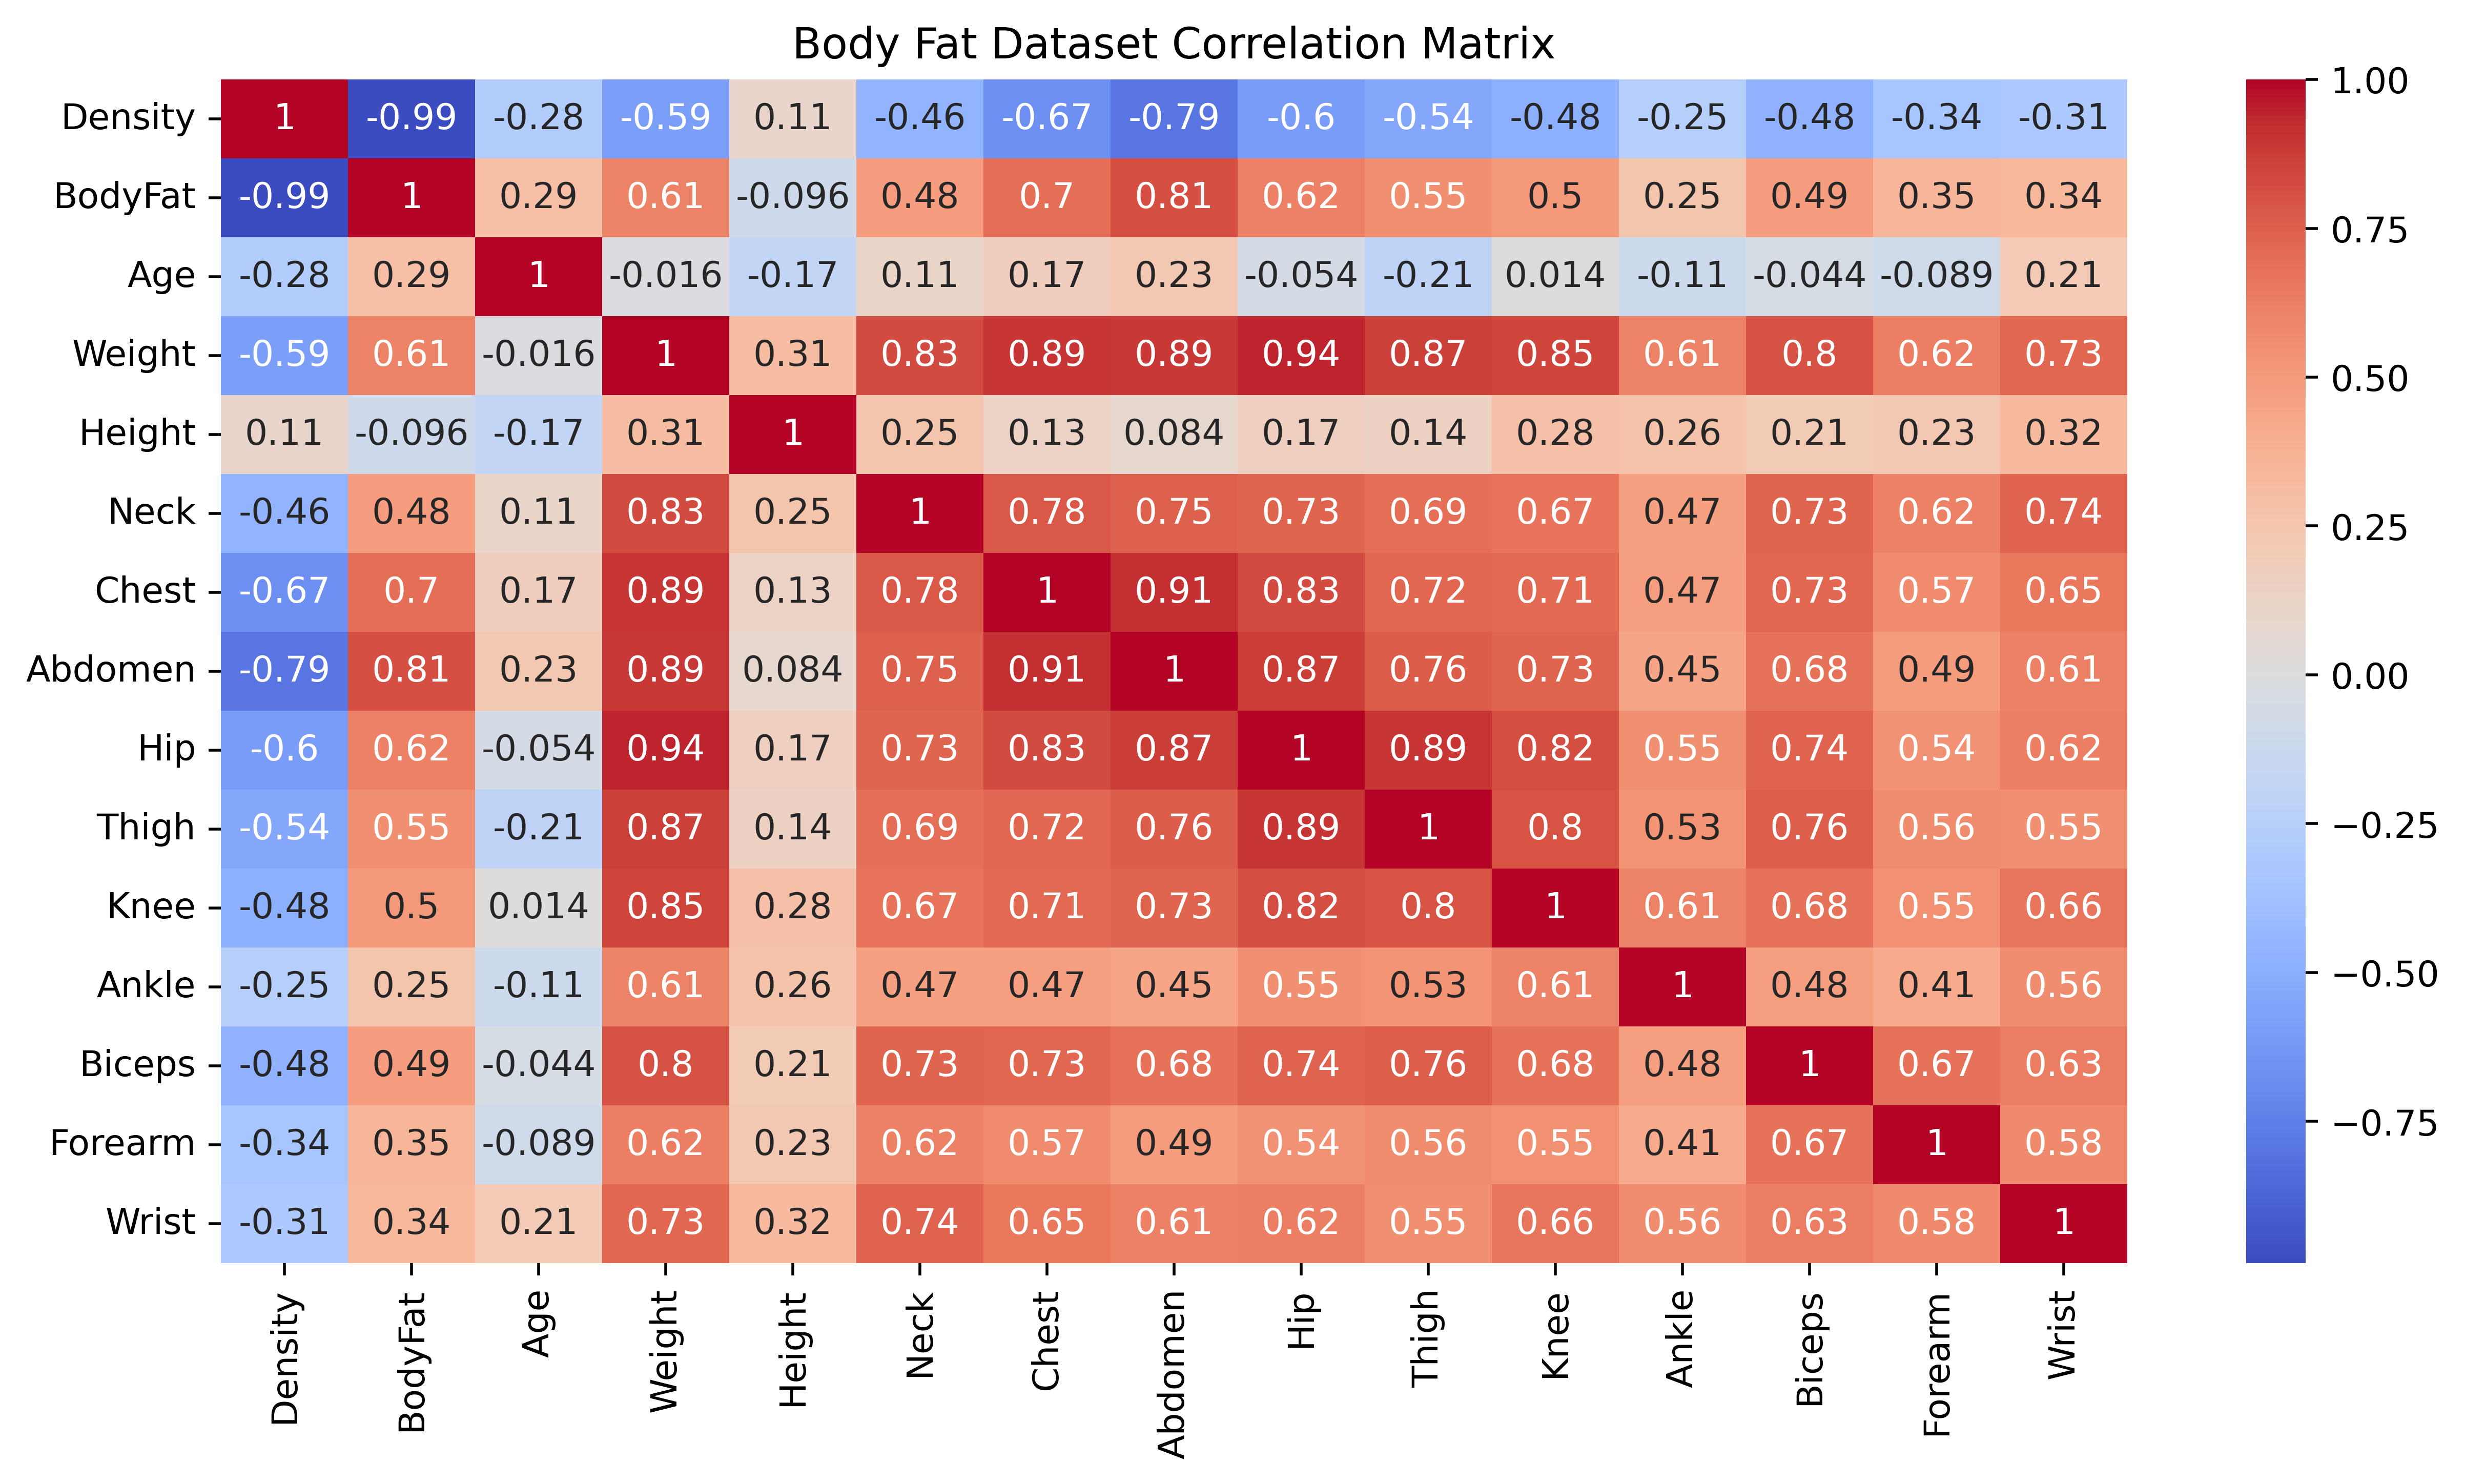

In [10]:
## Correlation
corr_bf = data_bf.corr(method = 'pearson')

## Displayed in heatmap
plt.figure(figsize=(12,6), dpi = 500)
sns.heatmap(corr_bf, annot = True, cmap = "coolwarm")
plt.title("Body Fat Dataset Correlation Matrix")
plt.show()

The heatmap shows a strong negative correlation of -0.99 between BodyFat and Density. Additionally, according to the dataset description, body fat percentage can be estimated from density, indicating a direct relationship between the two variables. Thus, to prevent multicollinearity, Density will be excluded from further analysis. 

In [11]:
## Dropping 'Density' column
data_bf = data_bf.drop(columns = ['Density'])

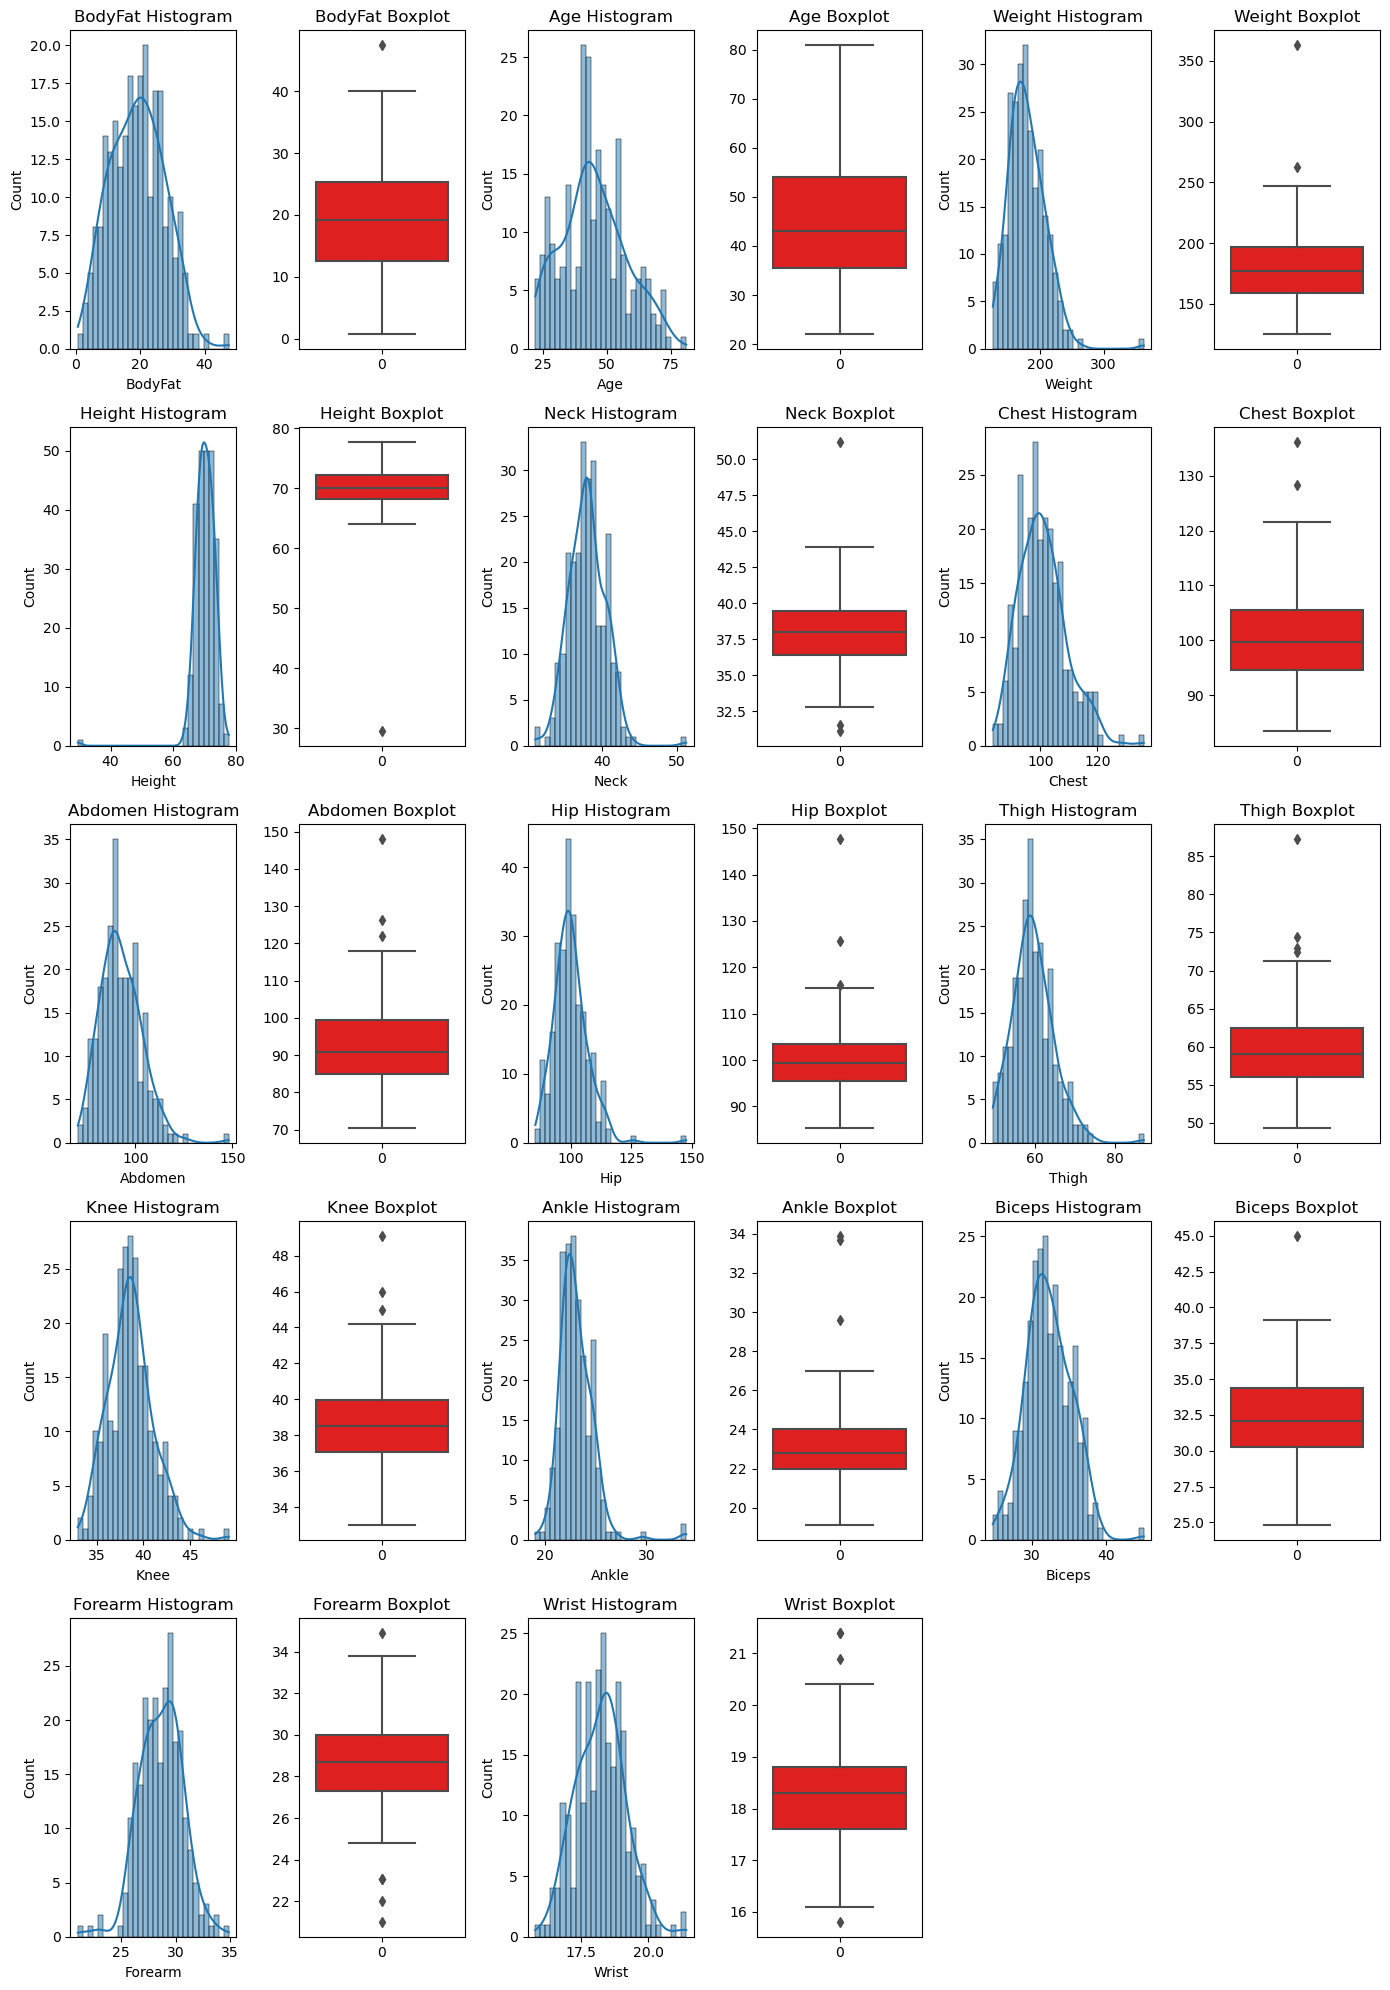

In [12]:
## Plotting Histogram with KDE and Boxplot
fig_col = 6 
fig_row = 5
fig, axes = plt.subplots(fig_row, fig_col, figsize = (14,20))
axes = axes.flatten()

for i, col in enumerate(data_bf.columns):
    sns.histplot(data_bf[col], kde = True, bins = 30, ax = axes[i * 2])
    axes[i * 2].set_title(f"{col} Histogram")
    sns.boxplot(data_bf[col], ax = axes[i * 2 + 1], color = 'red')
    axes[i * 2 + 1].set_title(f"{col} Boxplot")

fig.delaxes(axes[28])             ## Removing the 29th empty subplot   
fig.delaxes(axes[29])             ## Removing the 30th empty subplot        
plt.tight_layout()
plt.show()

As observed, outliers are present and will be excluded from the analysis.

In [13]:
## Removing outliers using Interquartile Range
q1 = data_bf.quantile(0.25)
q3 = data_bf.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
upper_bound = q3 + 1.5*iqr
data_bf = data_bf[~((data_bf < lower_bound) | (data_bf > upper_bound)).any(axis=1)]

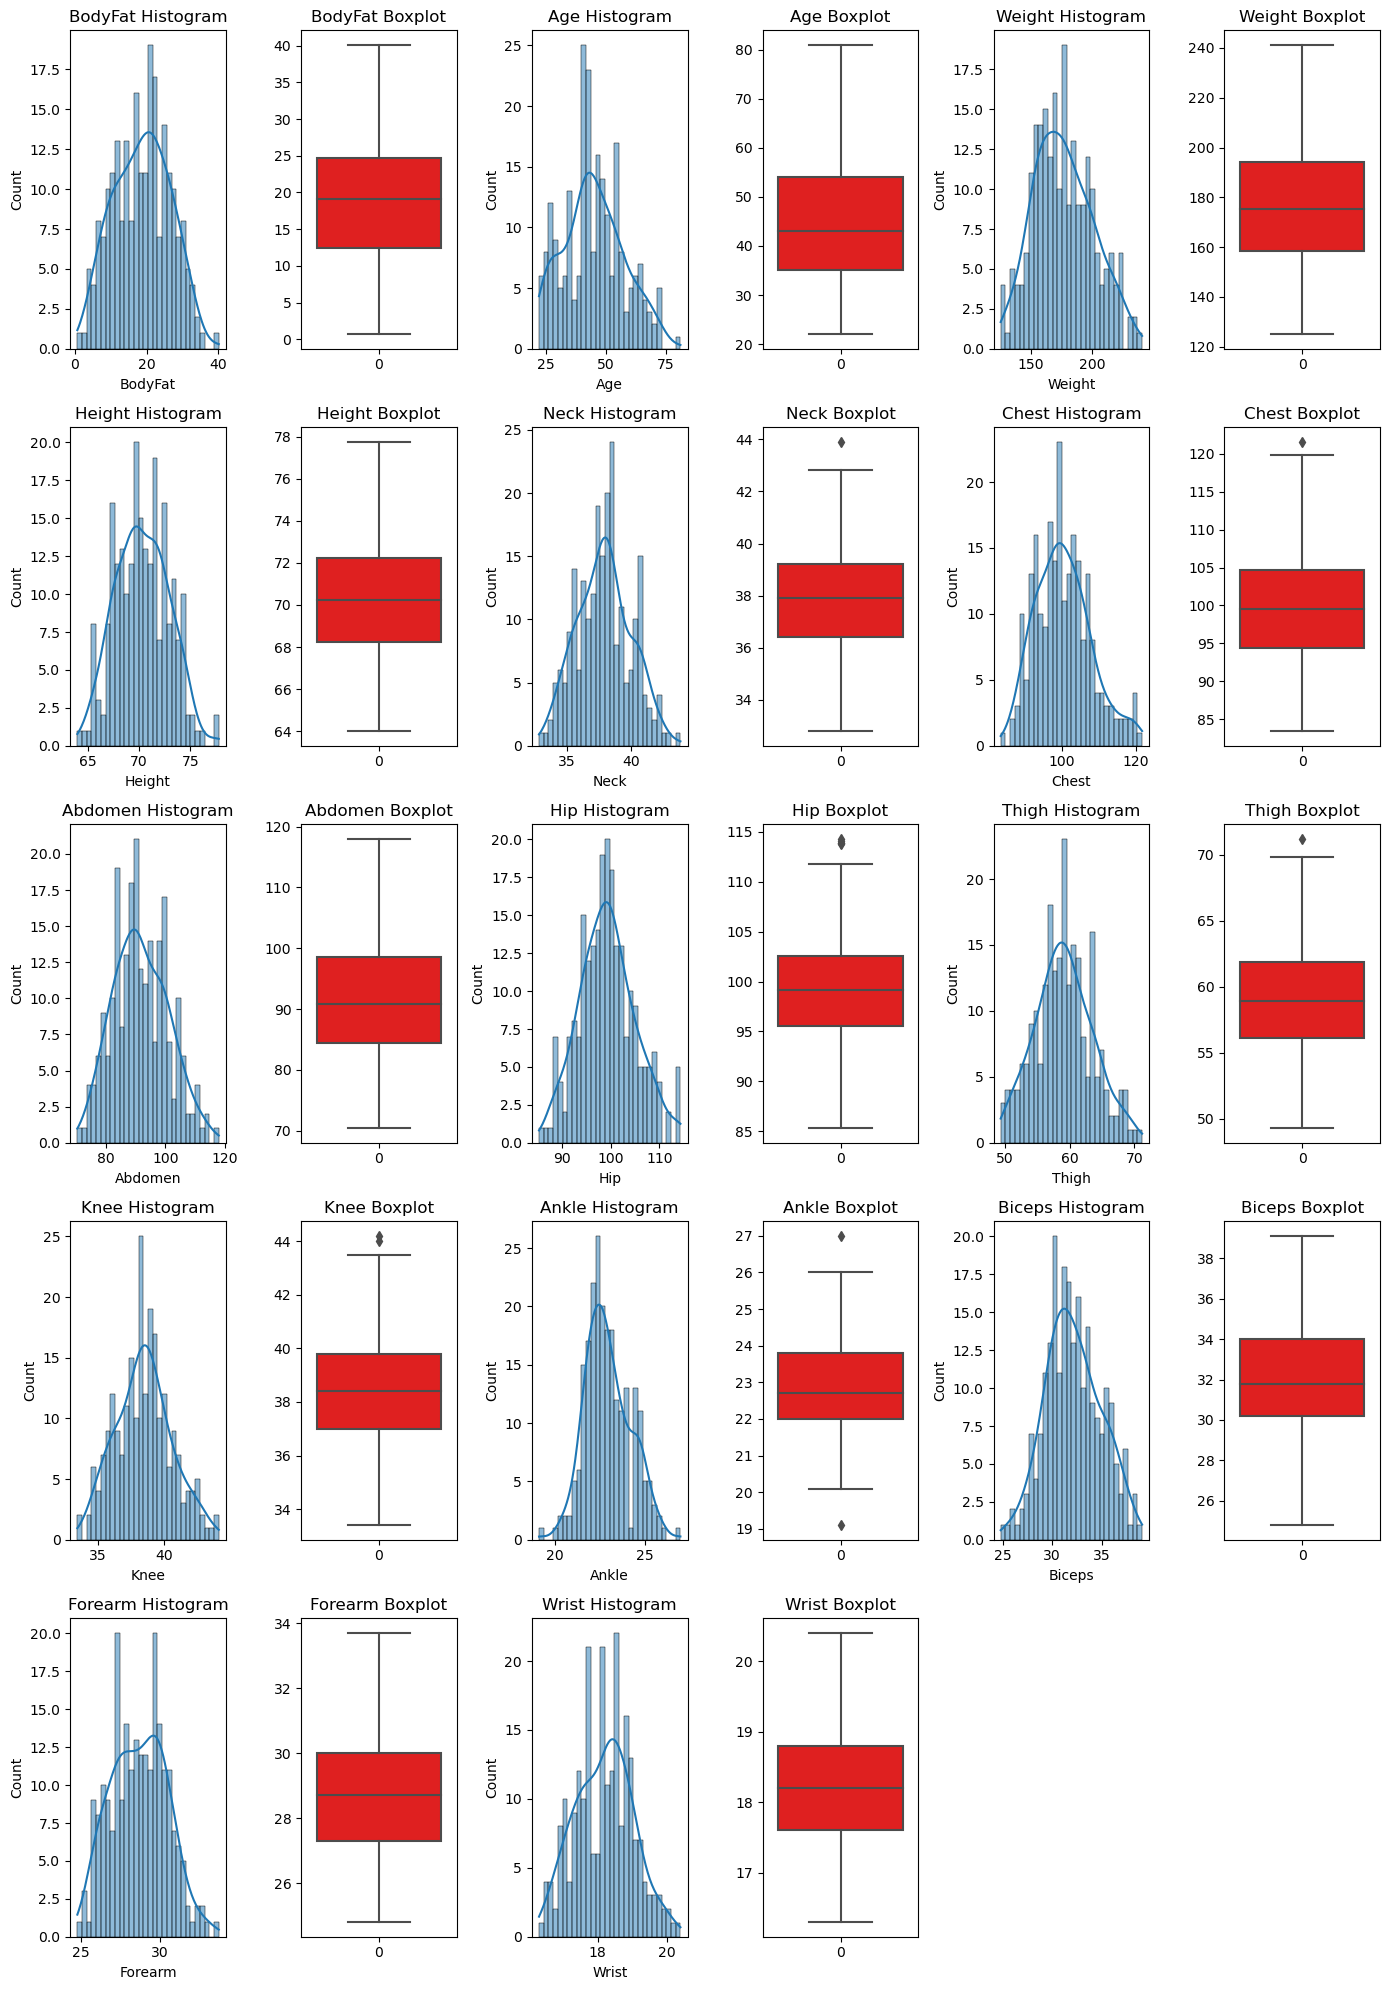

In [14]:
## Checking that outliers are removed
fig_col = 6 
fig_row = 5
fig, axes = plt.subplots(fig_row, fig_col, figsize = (14,20))
axes = axes.flatten()

for i, col in enumerate(data_bf.columns):
    sns.histplot(data_bf[col], kde = True, bins = 30, ax = axes[i * 2])
    axes[i * 2].set_title(f"{col} Histogram")
    sns.boxplot(data_bf[col], ax = axes[i * 2 + 1], color = 'red')
    axes[i * 2 + 1].set_title(f"{col} Boxplot")

fig.delaxes(axes[28])             ## Removing the 29th empty subplot   
fig.delaxes(axes[29])             ## Removing the 30th empty subplot        
plt.tight_layout()
plt.show()

### Heart Failure Clinical Records Dataset

In [15]:
## Checking for duplicated values
data_hfcr.duplicated().sum()

0

In [16]:
## Checking for NA values
data_hfcr.isna().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

No duplicates and missing values

In [17]:
## Summary Statistics
data_hfcr.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


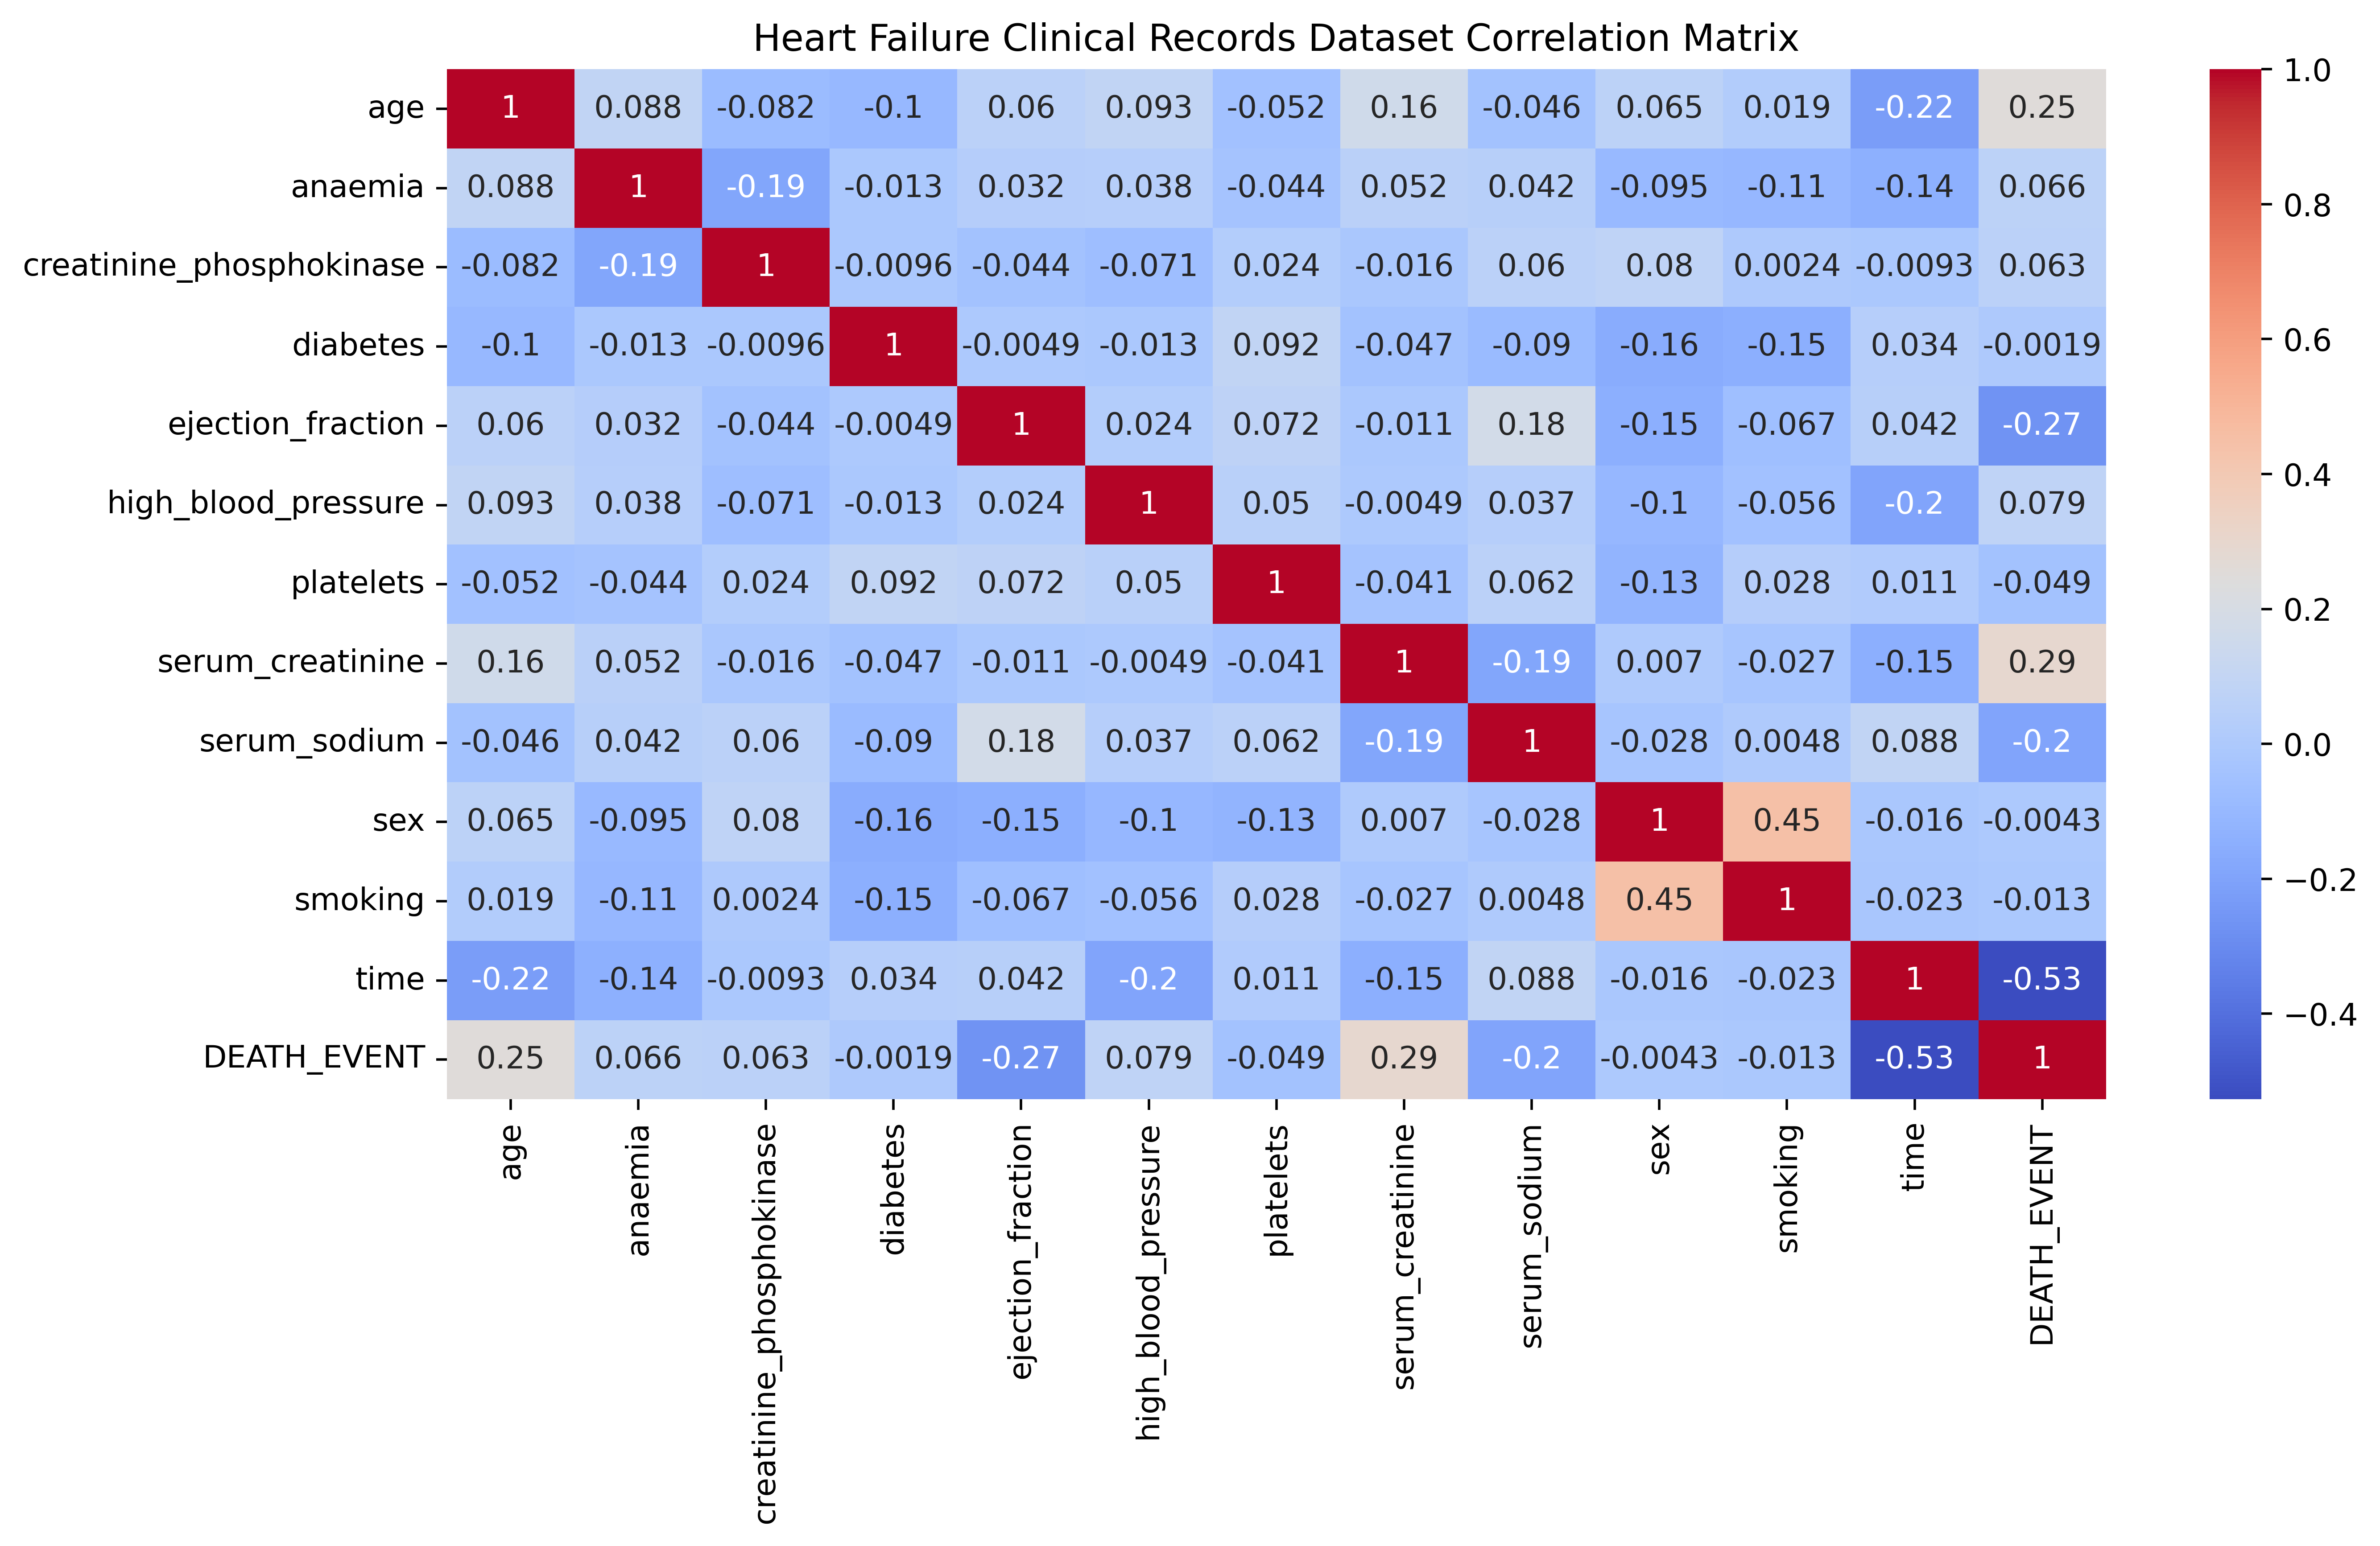

In [18]:
## Correlation
corr_hfcr = data_hfcr.corr(method = 'pearson')

## Displayed in heatmap
plt.figure(figsize=(12,6), dpi = 500)
sns.heatmap(corr_hfcr, annot = True, cmap = "coolwarm")
plt.title("Heart Failure Clinical Records Dataset Correlation Matrix")
plt.show()

In [19]:
## Segregating categorical and continuous variables
categorical_hfcr = data_hfcr[['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking', 'DEATH_EVENT']]
continuous_hfcr = data_hfcr[['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'time']]

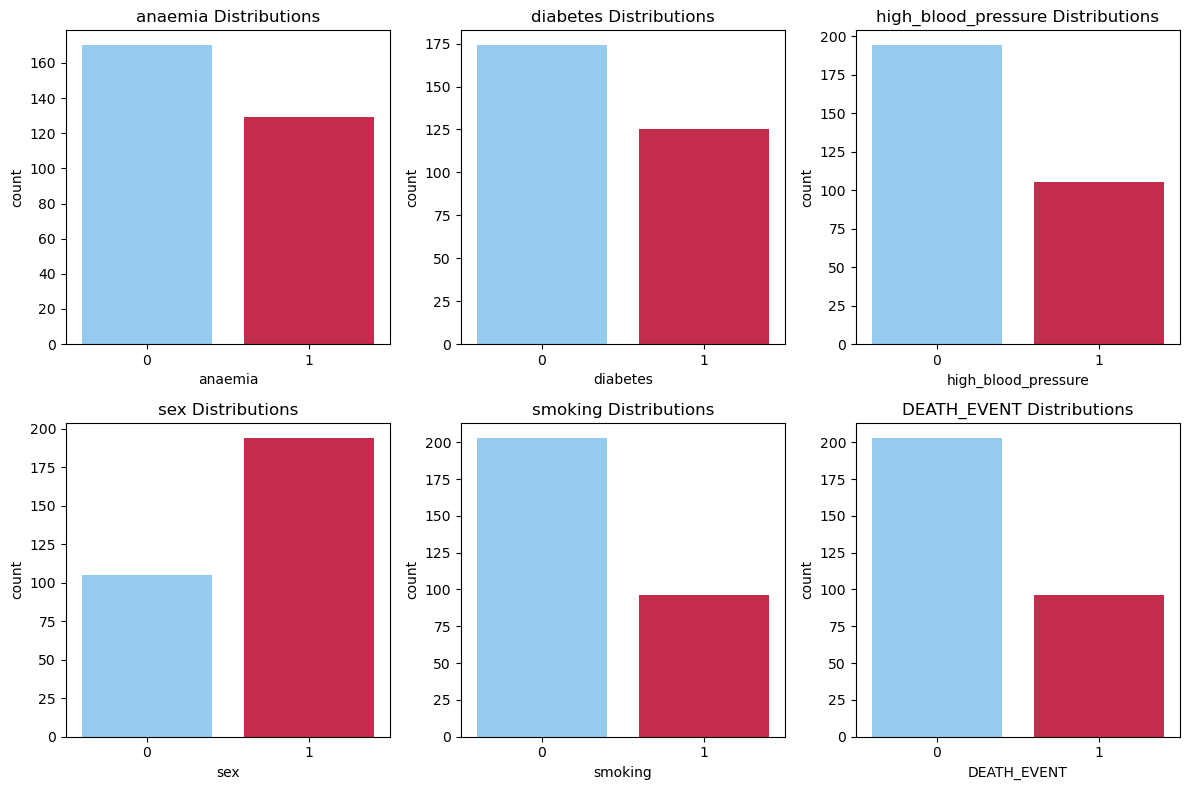

In [20]:
## Countplot for categorical variables
data_hfcr[categorical_hfcr.columns] = data_hfcr[categorical_hfcr.columns].astype(str)   ## Converting data into strings to ensure data is interpretated correctly 

fig_col = 3 
fig_row = 2
fig, axes = plt.subplots(fig_row, fig_col, figsize = (12,8))
axes = axes.flatten()

for i, col in enumerate(categorical_hfcr.columns):
    sns.countplot(x = data_hfcr[col], ax = axes[i], order = ['0', '1'], palette = {"0": "lightskyblue", "1": "crimson"})
    axes[i].set_title(f"{col} Distributions")
    
plt.tight_layout()
plt.show()

It can be noted that target variable, 'DEATH_EVENT' has class imbalances.

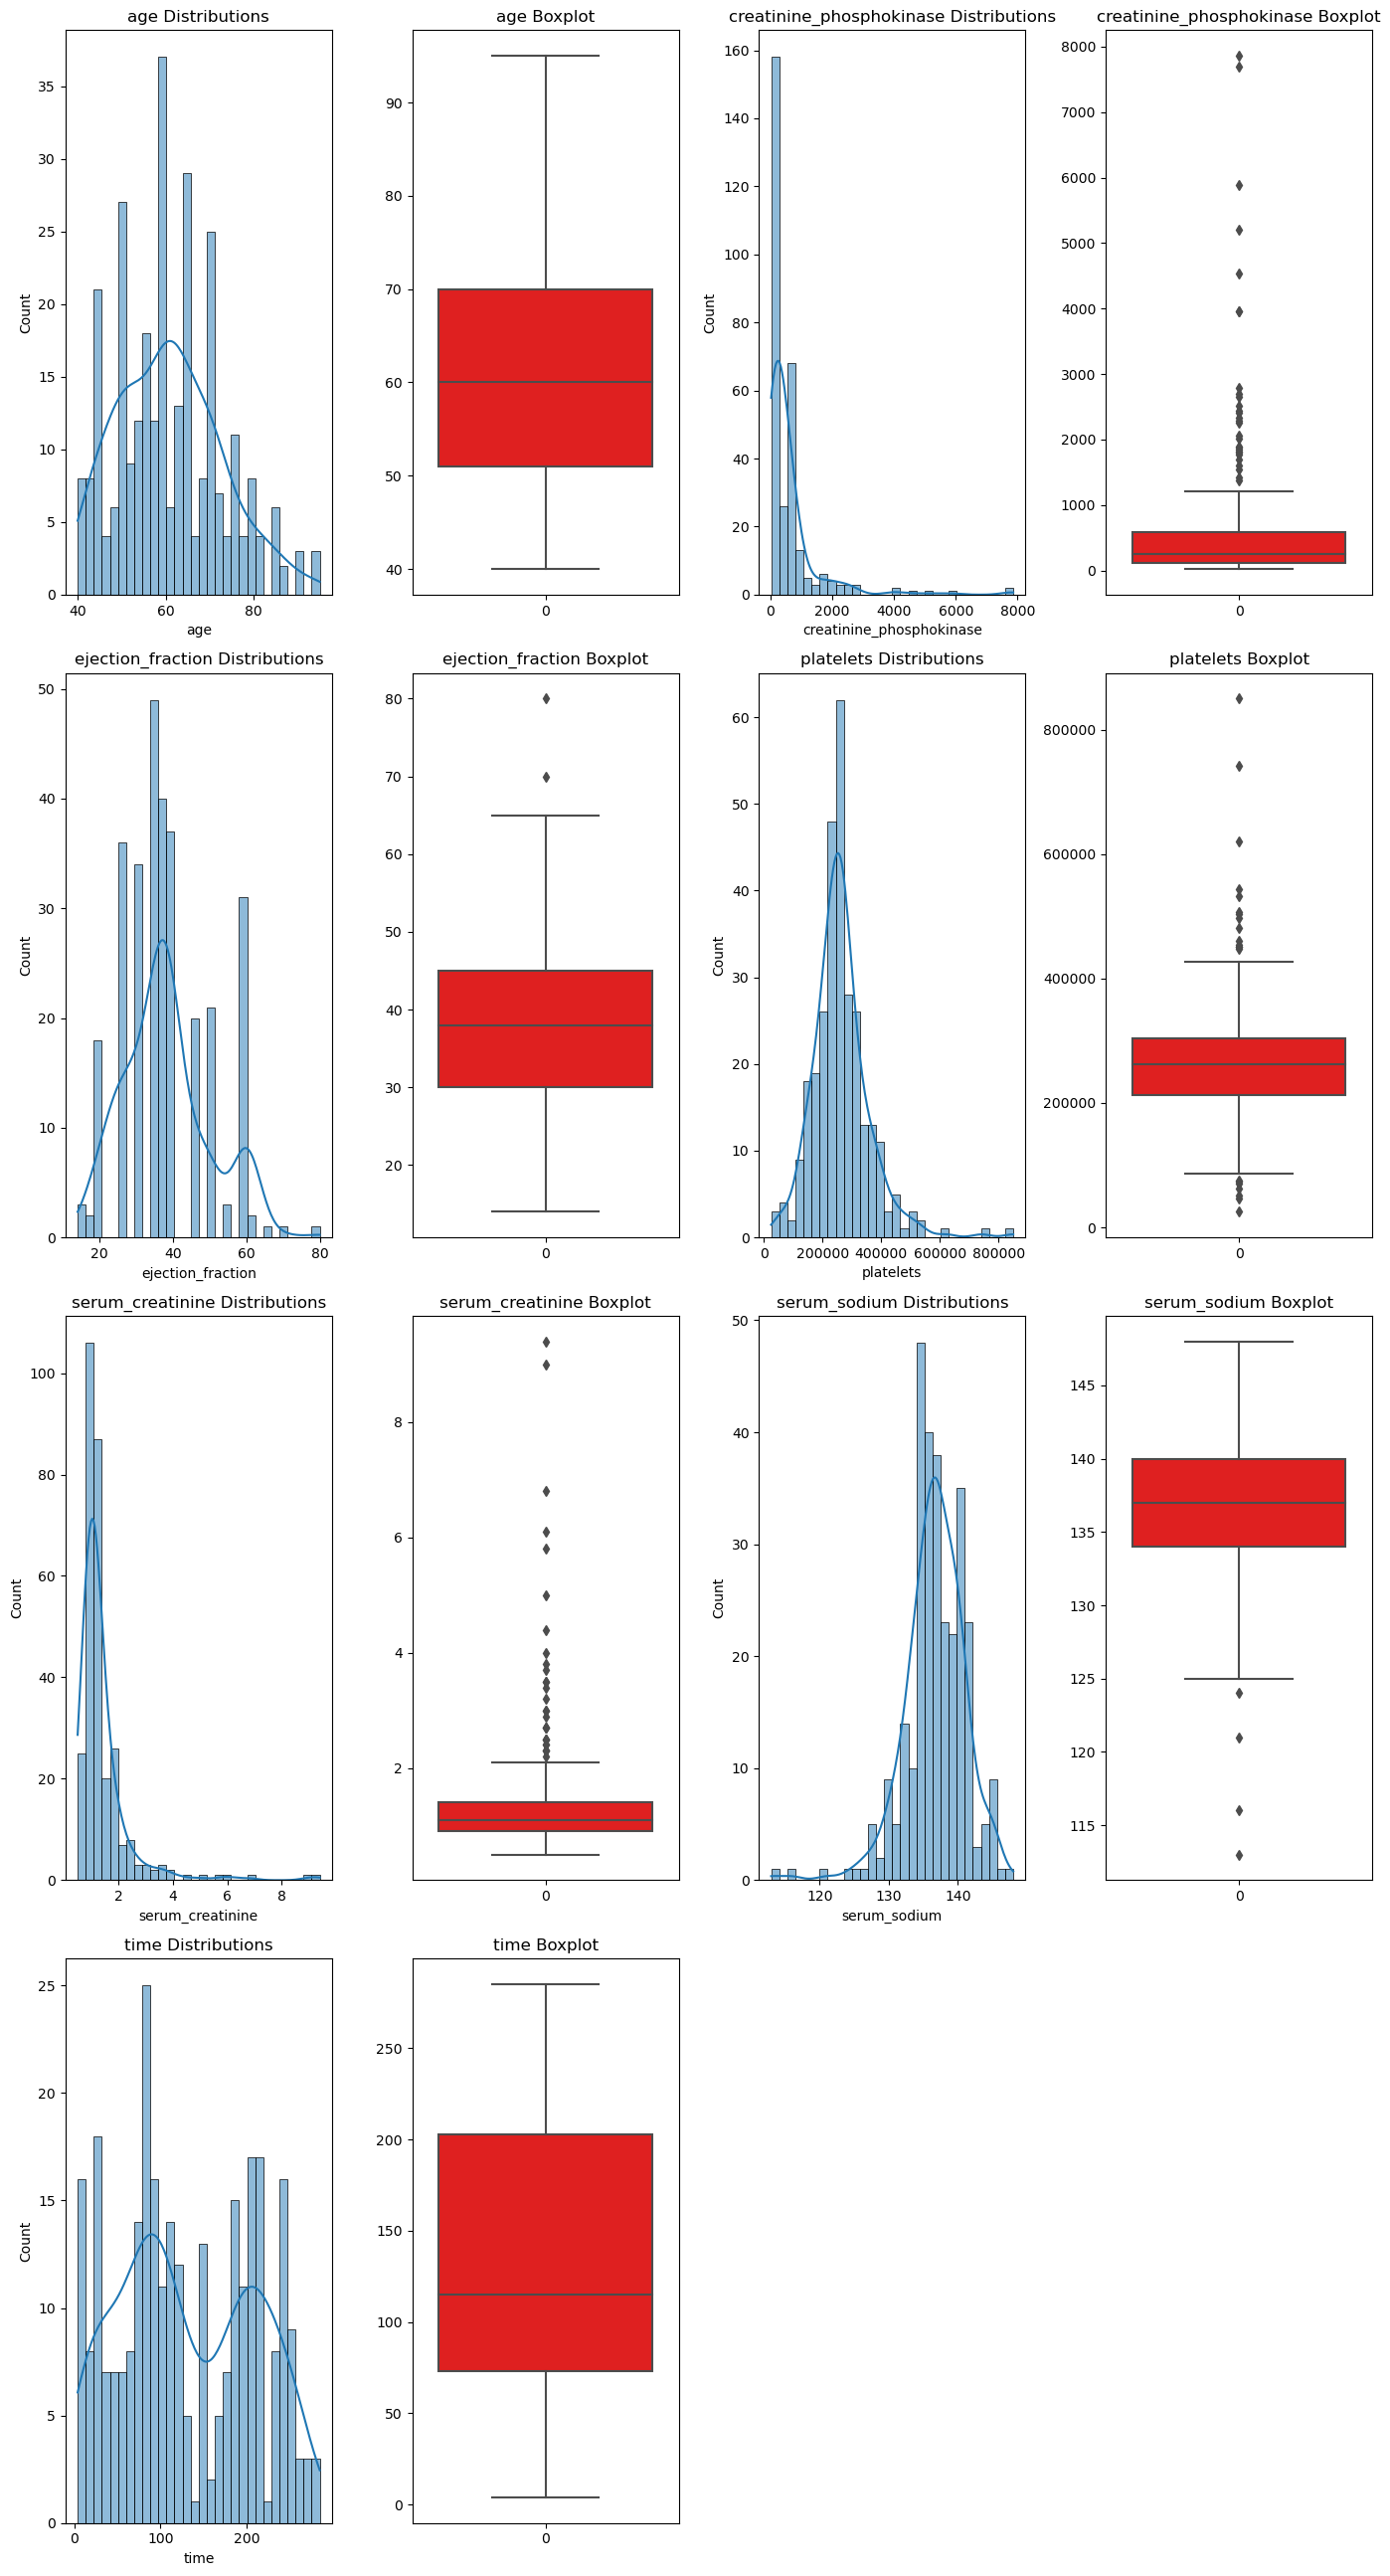

In [21]:
## Histogram with KDE and Boxplots for continuous variables 
fig_col = 4
fig_row = 4
fig, axes = plt.subplots(fig_row, fig_col, figsize = (14,26))
axes = axes.flatten()

for i, col in enumerate(continuous_hfcr.columns):
    sns.histplot(data_hfcr[col], kde = True, bins = 30, ax = axes[i * 2])
    axes[i * 2].set_title(f"{col} Distributions")
    sns.boxplot(data_hfcr[col], ax = axes[i * 2 + 1], color = 'red')
    axes[i * 2 + 1].set_title(f"{col} Boxplot")
    
fig.delaxes(axes[14])             ## Removing the 15th empty subplot
fig.delaxes(axes[15])             ## Removing the 16th empty subplot
plt.tight_layout()
plt.show()

As observed, outliers are present and will be excluded from the analysis.

In [22]:
## Removing outliers using Interquartile Range
q1hfcr = continuous_hfcr.quantile(0.25)
q3hfcr = continuous_hfcr.quantile(0.75)
iqrhfcr = q3hfcr - q1hfcr
lower_boundhfcr = q1hfcr - 1.5*iqrhfcr
upper_boundhfcr = q3hfcr + 1.5*iqrhfcr
data_hfcr = data_hfcr[~((continuous_hfcr < lower_boundhfcr) | (continuous_hfcr > upper_boundhfcr)).any(axis=1)]

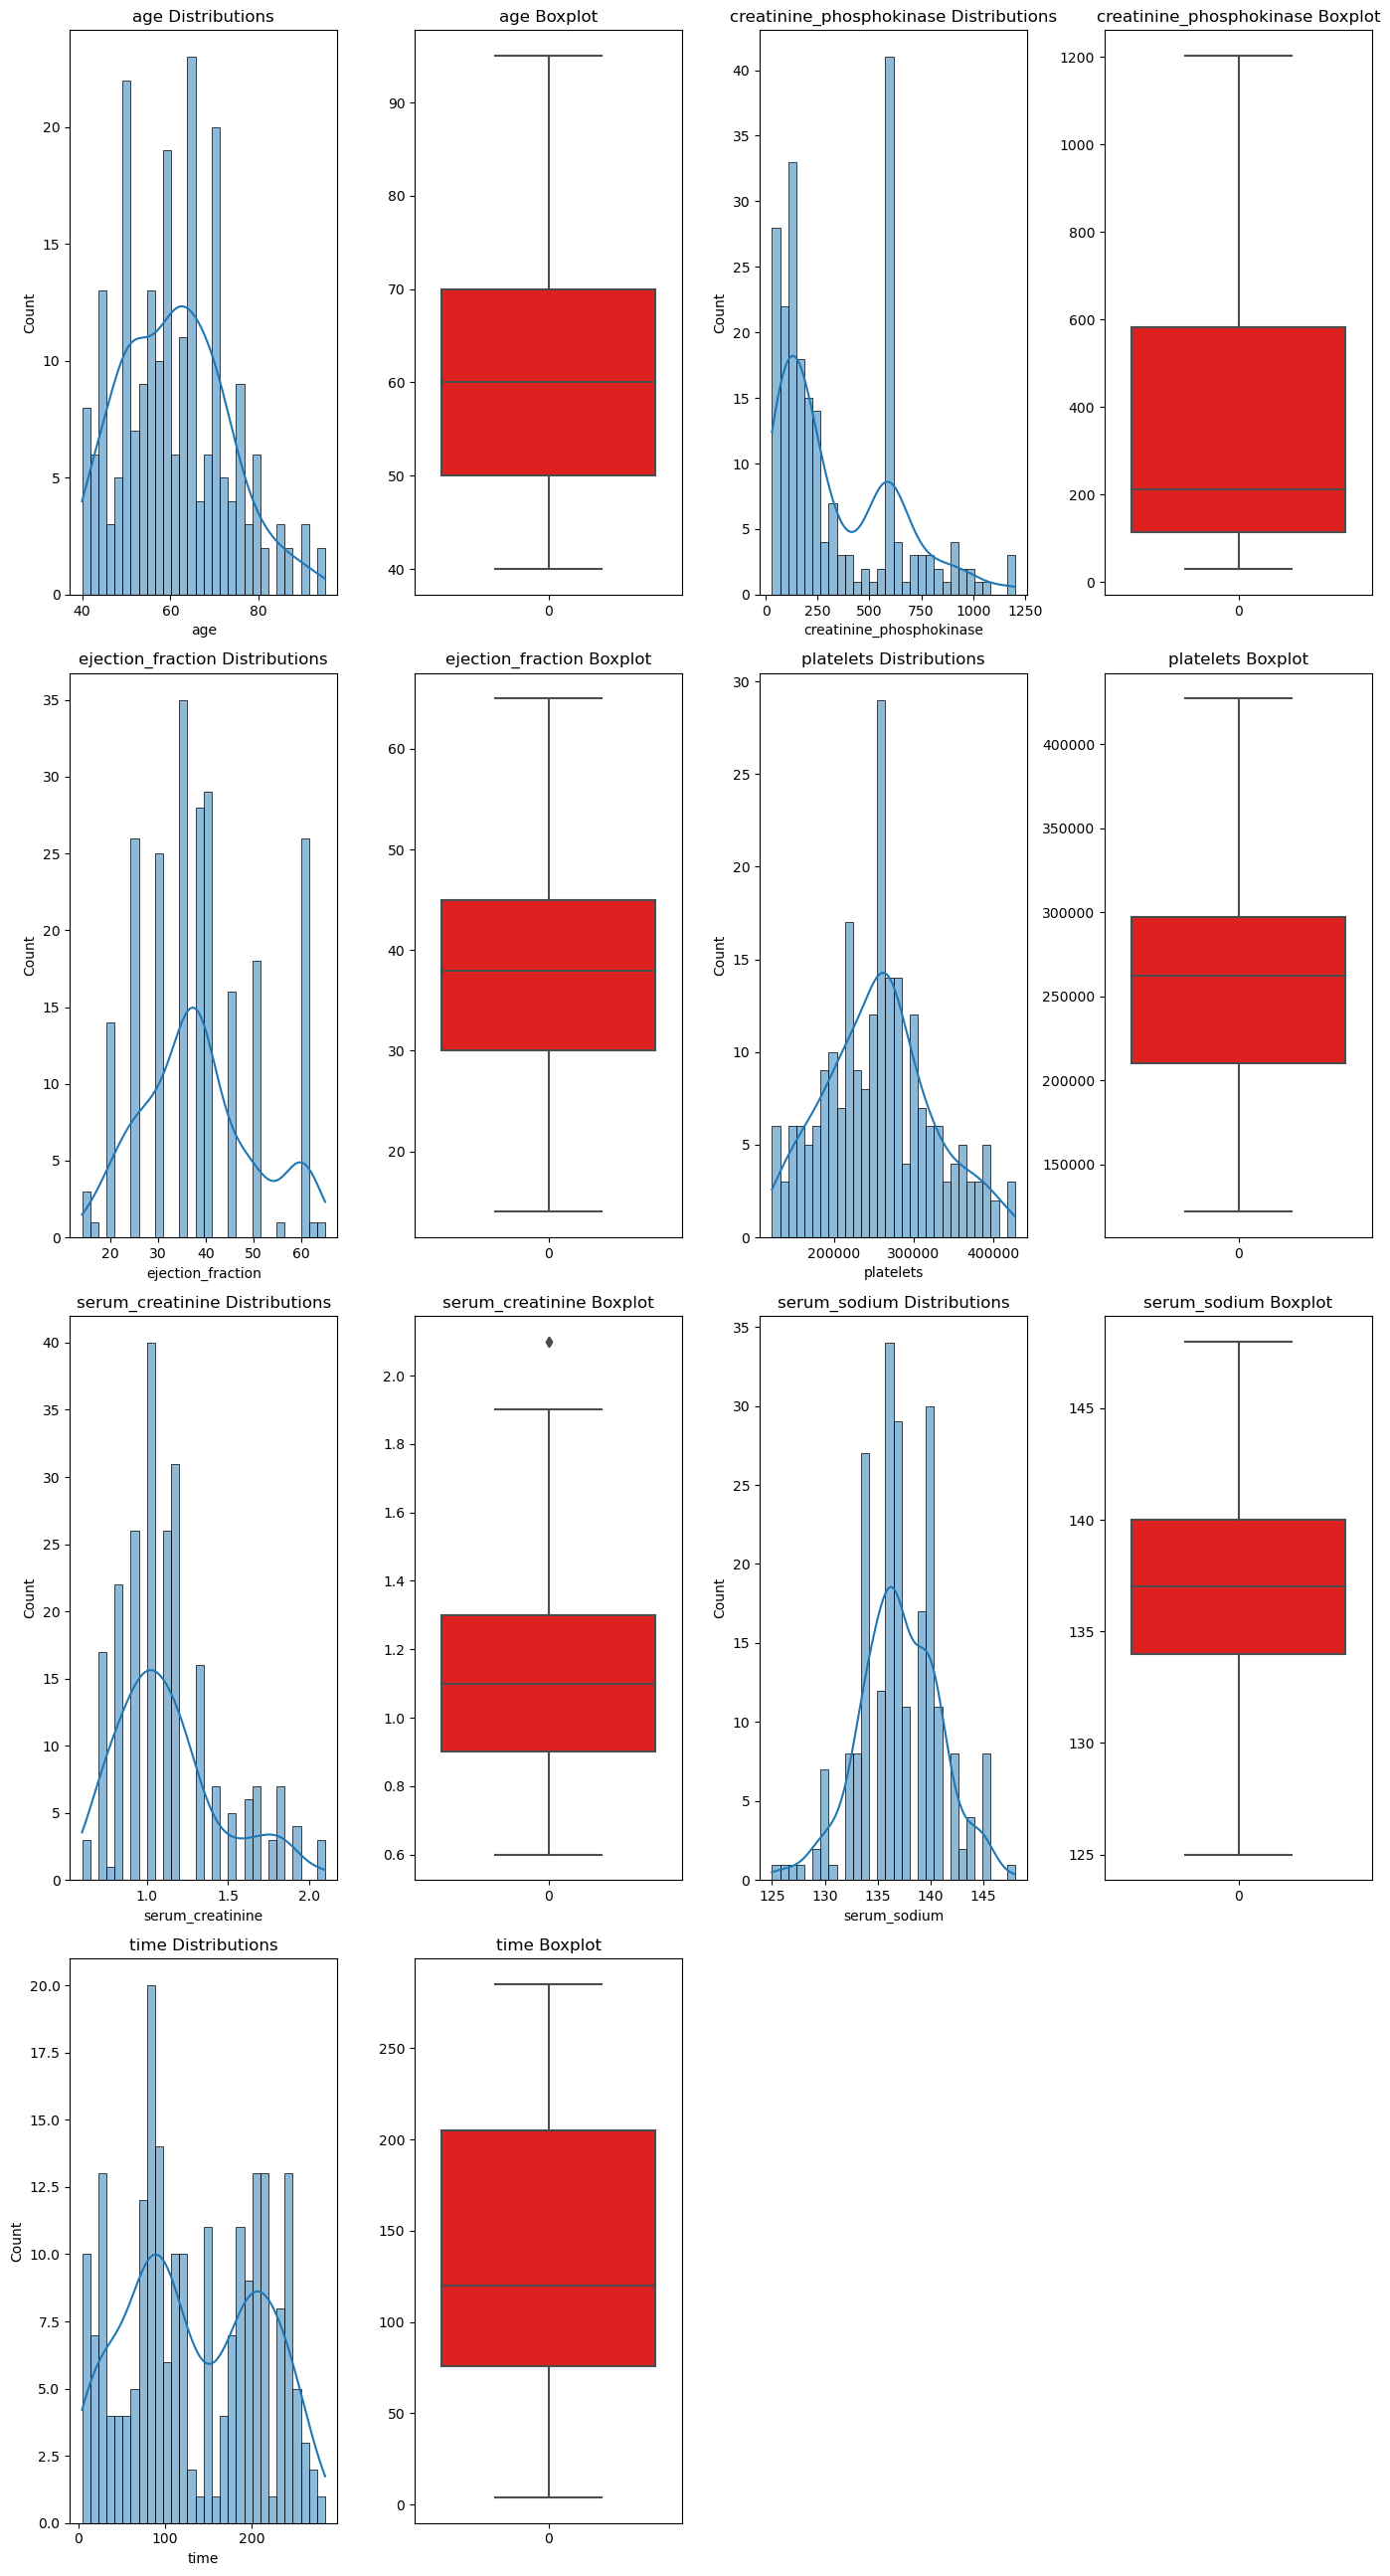

In [23]:
## Ensuring that outliers are removed
fig_col = 4
fig_row = 4
fig, axes = plt.subplots(fig_row, fig_col, figsize = (14,26))
axes = axes.flatten()

for i, col in enumerate(continuous_hfcr.columns):
    sns.histplot(data_hfcr[col], kde = True, bins = 30, ax = axes[i * 2])
    axes[i * 2].set_title(f"{col} Distributions")
    sns.boxplot(data_hfcr[col], ax = axes[i * 2 + 1], color = 'red')
    axes[i * 2 + 1].set_title(f"{col} Boxplot")
    
fig.delaxes(axes[14])             ## Removing the 15th empty subplot
fig.delaxes(axes[15])             ## Removing the 16th empty subplot
plt.tight_layout()
plt.show()

## Unsupervised Learning using Body Fat Prediction Dataset

### Data Scaling

In [24]:
## Removing 'BodyFat' column from dataset
data_bf_nobf = data_bf.drop(columns = 'BodyFat')

In [25]:
## Standardising
ss = StandardScaler()
scaled_data_bf_nobf = ss.fit_transform(data_bf_nobf)
scaled_data_bf_nobf

array([[-1.73792205, -0.92053922, -0.99403706, ..., -0.05304509,
        -0.72186327, -1.30265767],
       [-1.81739915, -0.14360994,  0.75764001, ..., -0.59041493,
         0.12532012,  0.02012823],
       [-1.81739915, -0.93076197, -1.57792942, ..., -1.19943409,
        -1.9643989 , -1.90392399],
       ...,
       [ 2.15645597,  0.99111571, -0.21551392, ...,  1.09334391,
        -0.04411656,  2.30494023],
       [ 2.15645597,  0.40841875, -1.67524481, ..., -0.30381768,
        -0.83482105, -0.2203783 ],
       [ 2.15645597,  0.57198281,  0.07643226, ..., -0.59041493,
         0.40771458,  1.94418044]])

In [26]:
## Ensuring all variables are standardised
mean = scaled_data_bf_nobf.mean(axis = 0)
std_dev = scaled_data_bf_nobf.std(axis = 0)
print(mean)
print(std_dev)

[ 2.53492982e-16 -9.75852684e-16 -1.33417359e-15  2.91612228e-15
  2.71409028e-15  5.71788682e-16 -1.58957254e-15 -4.86020380e-16
  1.37229284e-16  5.02221059e-15  8.23375702e-16 -4.57430946e-16
 -3.62132832e-15]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [27]:
## Structuring into a dataframe
scaled_data_bf_nobf = pd.DataFrame(scaled_data_bf_nobf, columns = data_bf_nobf.columns)
scaled_data_bf_nobf.head()

,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,-1.737922,-0.920539,-0.994037,-0.804247,-0.968403,-0.710999,-0.841103,-0.020315,-0.545290,-0.820754,-0.053045,-0.721863,-1.302658
1,-1.817399,-0.143610,0.757640,0.287711,-0.901496,-0.949083,-0.109260,-0.087935,-0.545290,0.367045,-0.590415,0.125320,0.020128
2,-1.817399,-0.930762,-1.577929,-1.848729,-0.607104,-0.418806,-0.022136,0.114924,0.203454,0.842165,-1.199434,-1.964399,-1.903924
3,-1.499491,0.326637,0.757640,-0.234530,0.195783,-0.581136,0.326360,0.227624,-0.545290,-0.108074,0.090254,0.407715,0.020128
4,-1.658445,0.306191,0.368378,-1.658823,-0.406382,0.890654,0.448334,0.926361,1.747740,0.842165,0.018604,-0.552427,-0.581138


### Principal Component Analysis (PCA)

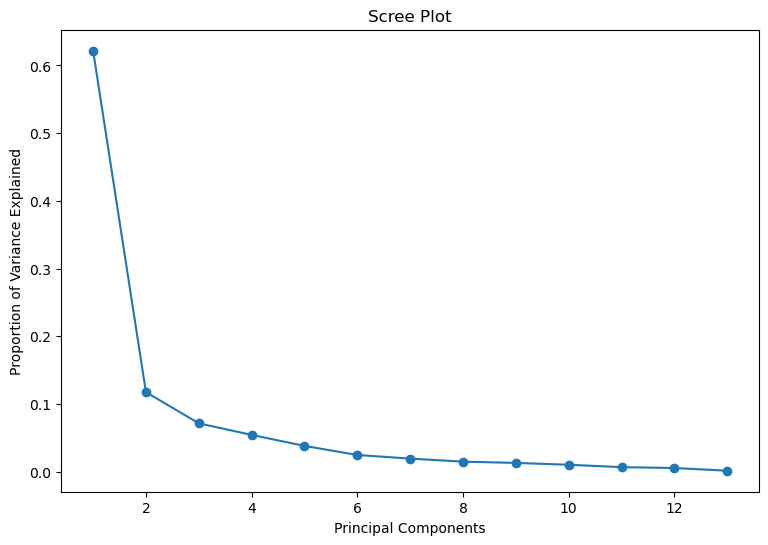

In [28]:
pca = PCA()
pca.fit(scaled_data_bf_nobf)

variance_explained = pca.explained_variance_ratio_      ## Proportion of total variance explained by each PC

## Scree Plot
plt.figure(figsize = (9,6))
plt.plot(range(1, len(variance_explained) + 1), variance_explained, marker = 'o', linestyle = '-')
plt.xlabel("Principal Components")
plt.ylabel("Proportion of Variance Explained")
plt.title("Scree Plot")
plt.show()

It can be observed that the optimal number of principal components is at the 'elbow' - 2

In [29]:
pca2 = PCA(n_components = 2)
scaled_data_bf_nobf_pca = pca2.fit_transform(scaled_data_bf_nobf)
scaled_data_bf_nobf_pca = pd.DataFrame(scaled_data_bf_nobf_pca, columns = ['PC1', 'PC2'])

The optimal number of principal components will be used in the subsequent clustering methods.

### K-means Clustering

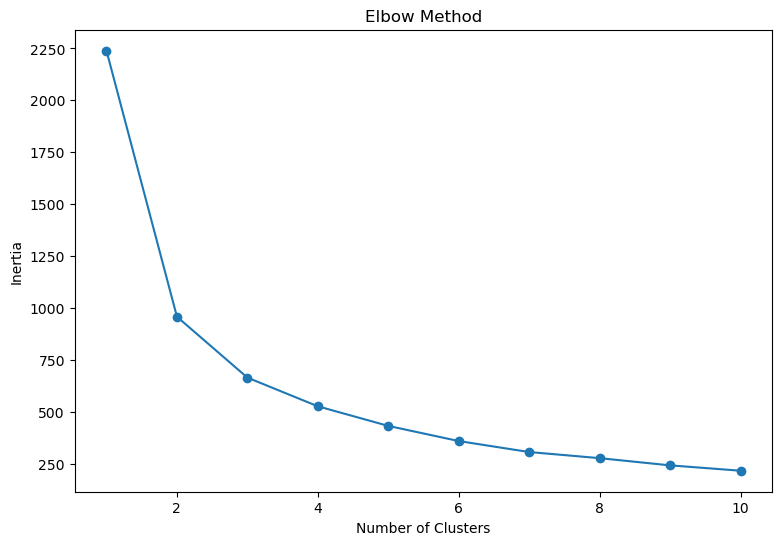

In [30]:
inertia = []       ## Determining optimal k by measuring inertia at different values of k

for k in range(1,11):
    kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)    ## Explicitly setting n_inint to avoid warning
    kmeans.fit(scaled_data_bf_nobf_pca)
    inertia.append(kmeans.inertia_)
    
## Elbow Method    
plt.figure(figsize = (9,6))
plt.plot(range(1,11), inertia, marker = 'o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

Optimal number of clusters is at the 'elbow' - 2

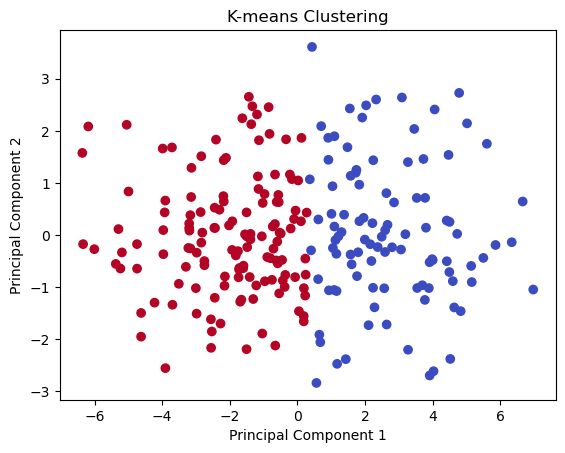

In [31]:
## 2 optimal clusters
kmeans = KMeans(n_clusters = 2, random_state = 42, n_init = 10)
clusters = kmeans.fit_predict(scaled_data_bf_nobf_pca)

## Visualising the clusters
plt.scatter(scaled_data_bf_nobf_pca.iloc[:, 0], scaled_data_bf_nobf_pca.iloc[:, 1], c = clusters, cmap = "coolwarm")
plt.title('K-means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### Hierarchical Clustering

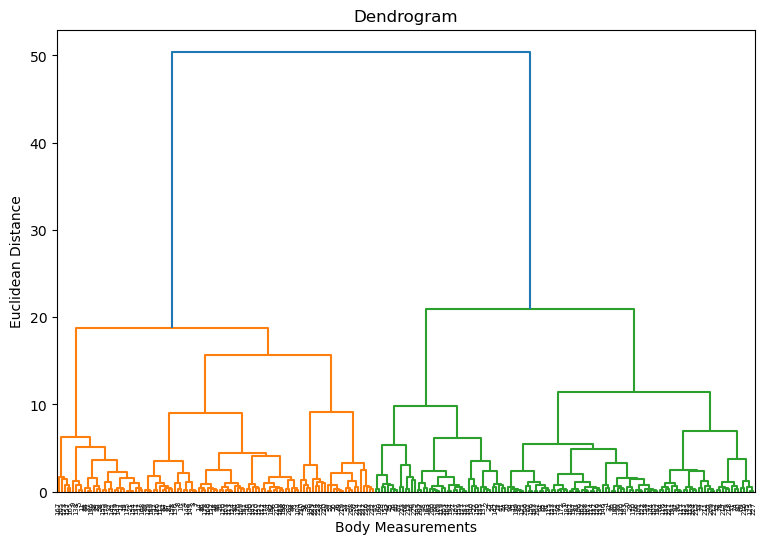

In [32]:
## Plotting Dendrogram
plt.figure(figsize = (9,6))
plt.xlabel('Body Measurements')
plt.ylabel('Euclidean Distance')
plt.title('Dendrogram')

linkage = linkage(scaled_data_bf_nobf_pca, method = 'ward', metric = 'euclidean')
dendrogram(linkage)

plt.show()

Optimal number of clusters is 2, based on the largest vertical gap between clusters.

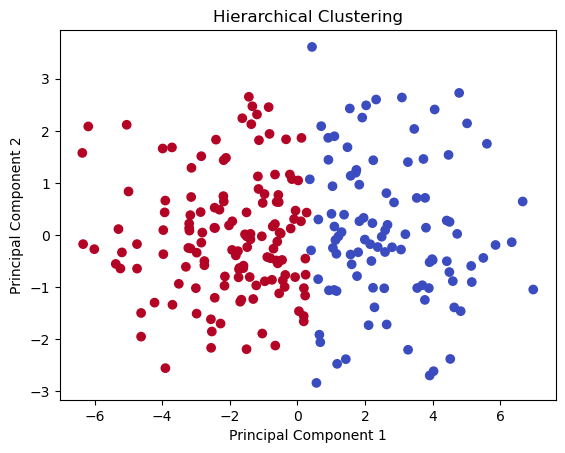

In [33]:
hierarchical_cluster = AgglomerativeClustering(n_clusters = 2, linkage = 'ward', metric = 'euclidean')
hclusters = hierarchical_cluster.fit_predict(scaled_data_bf_nobf_pca)

## Visualising clusters
plt.scatter(scaled_data_bf_nobf_pca.iloc[:, 0], scaled_data_bf_nobf_pca.iloc[:, 1], c = clusters, cmap = "coolwarm")
plt.title('Hierarchical Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

### Results

In [34]:
bf_ul = data_bf.copy()
bf_ul["Cluster"] = clusters          ## clusters from KMeans
cluster_summary = bf_ul.groupby("Cluster").mean()
cluster_summary

,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
Cluster,,,,,,,,,,,,,,
0,22.769697,44.828283,199.806061,71.404040,39.604040,106.677778,99.465657,104.244444,62.613131,40.149495,23.787879,34.392929,30.149495,18.786869
1,15.685075,44.895522,159.736940,69.490672,36.630597,95.652239,86.084328,95.694030,56.487313,37.220896,22.307463,30.489552,27.591045,17.737313


The features with the most difference of more than 4 units between the 2 clusters are Bodyfat, Weight, Chest, Abdomen, Hip and Thigh.

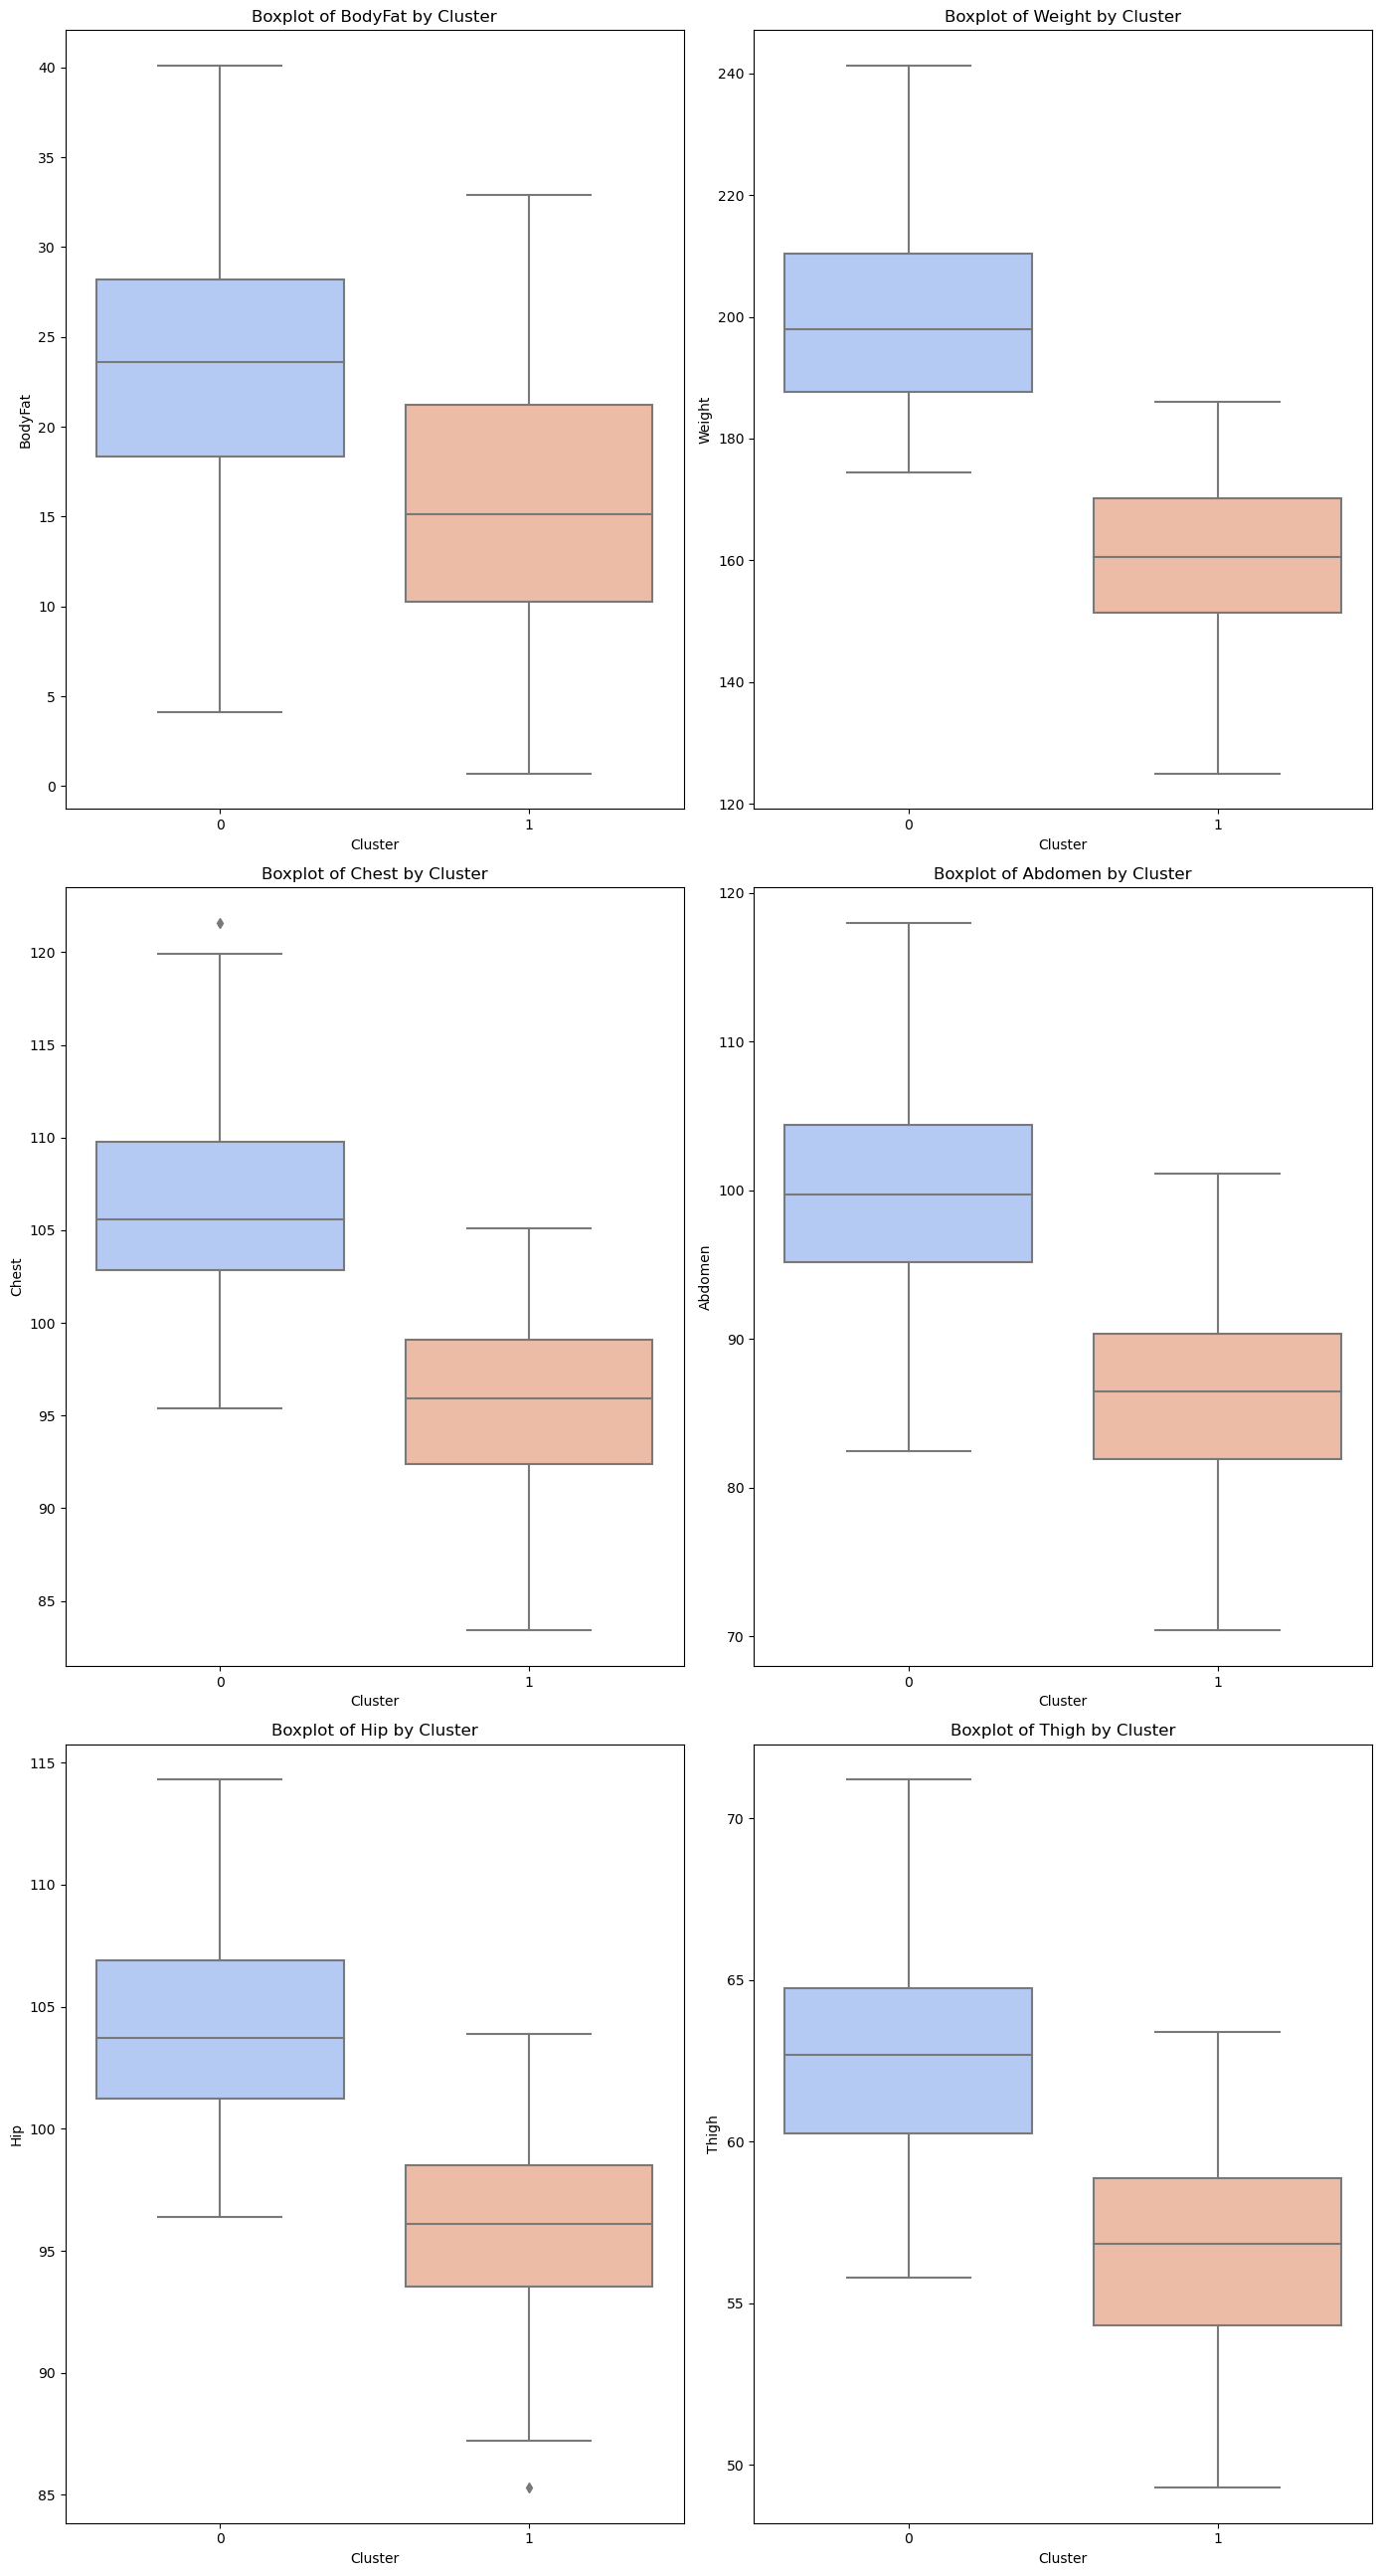

In [35]:
features_difference = ["BodyFat", "Weight", "Chest", "Abdomen", "Hip", "Thigh"]

## Boxplot to show difference in clusters
fig_col = 2
fig_row = 3
fig, axes = plt.subplots(fig_row, fig_col, figsize = (14,26))
axes = axes.flatten()

for i, feature in enumerate(features_difference):
    sns.boxplot(x = bf_ul["Cluster"], y = bf_ul[feature], ax = axes[i], palette = "coolwarm")
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel(feature)
    axes[i].set_title(f"Boxplot of {feature} by Cluster")


plt.tight_layout()
plt.show()

Cluster 0: Individuals had a higher body fat percentage, with higher weight, chest, abdomen, hip and thigh measurements.

Cluster 1: Individuals had a lower body fat percentage, with lower weight, chest, abdomen, hip and thigh measurements.

## Regression using Body Fat Prediction Dataset

In [36]:
X = data_bf.drop(columns = ['BodyFat'])
y = data_bf['BodyFat']

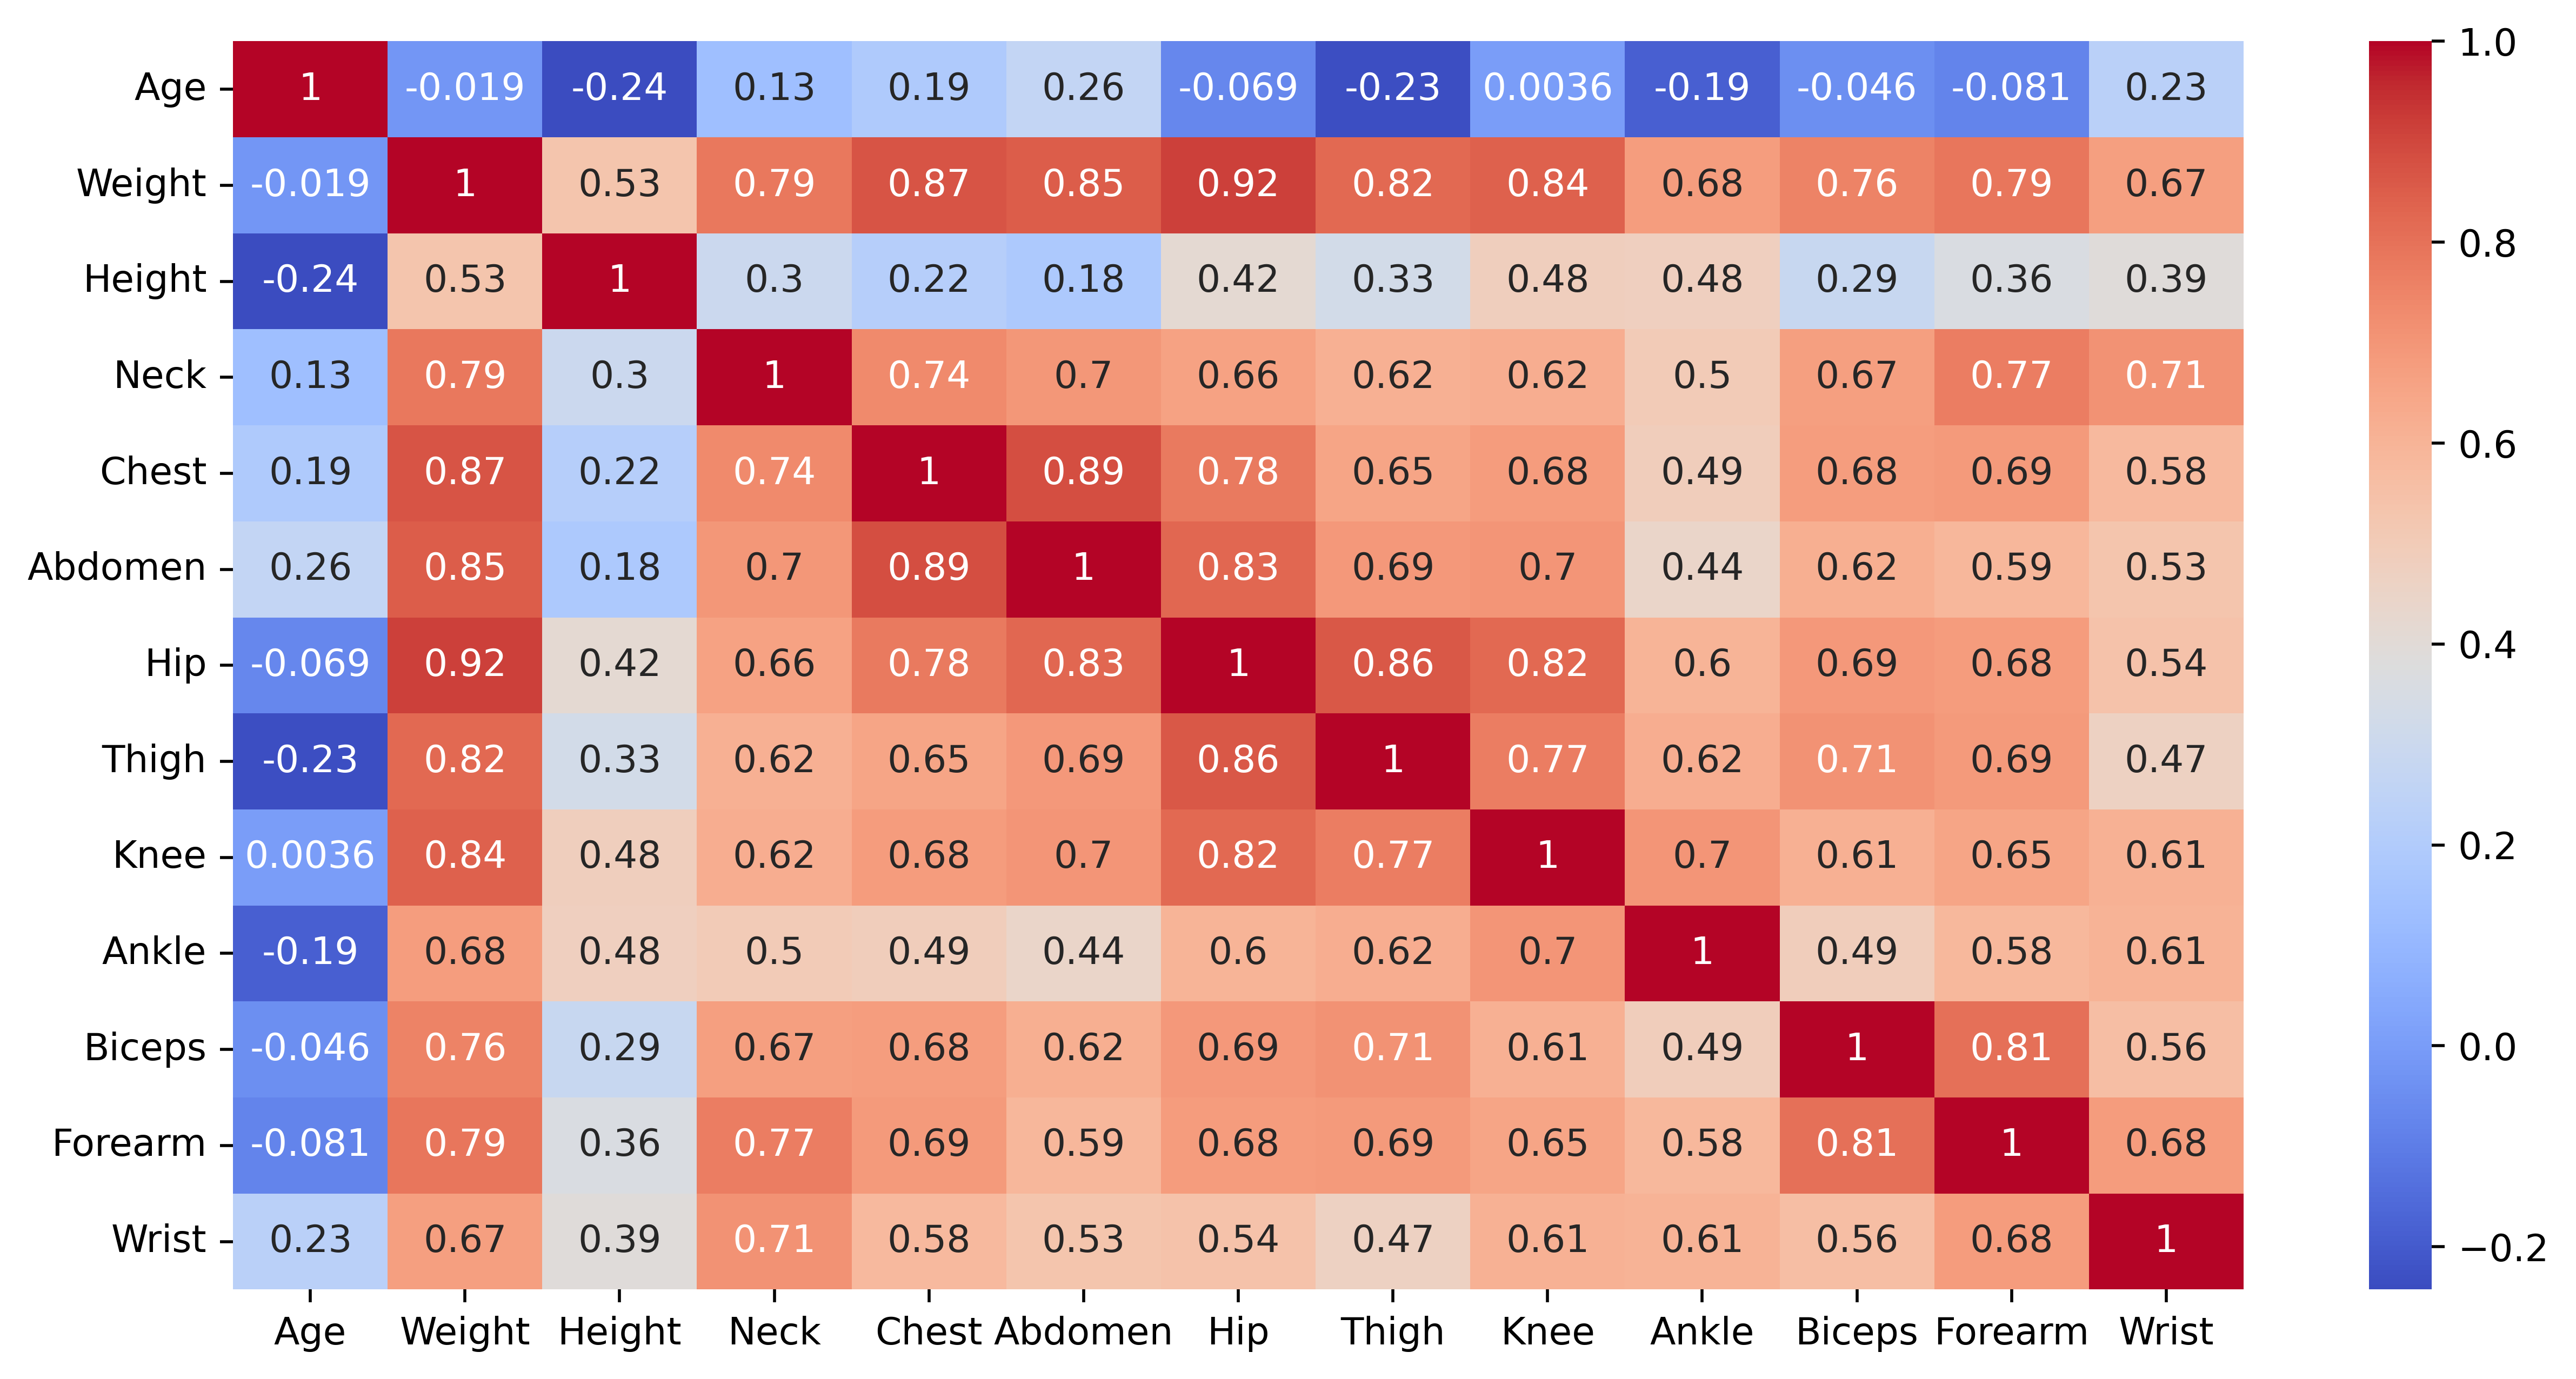

In [37]:
## Correlation Matrix
corr_X = X.corr(method = 'pearson')

plt.figure(figsize = (12,6), dpi = 500)
sns.heatmap(corr_X, annot = True, cmap = "coolwarm")
plt.show()

Multicollinearity is evident in the correlation matrix, which could interfere with selecting optimal features through methods such as P-values and Backward Elimination. Lasso Regression, which is a regularisation technique that mitigates multicollinearity while performing feature selection, will be used to identify the optimal features for future regression models.

### Lasso Regression for Feature Selection

In [38]:
## Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

## Standardising
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)

In [39]:
## Cross-validation to find optimal alpha
lasso_CV = Lasso()
lasso_param_grid = {'alpha': [0.1, 1, 10, 100, 1000]}
lasso_grid_search = GridSearchCV(lasso_CV, lasso_param_grid, cv = 10, scoring = 'neg_mean_squared_error')
lasso_grid_search.fit(X_train_scaled, y_train)
print(lasso_grid_search.best_params_)

{'alpha': 0.1}


Age: 0.722
Weight: -0.000
Height: -0.883
Neck: -0.376
Chest: -0.031
Abdomen: 6.798
Hip: -0.000
Thigh: 0.924
Knee: -0.001
Ankle: -0.148
Biceps: 0.000
Forearm: -0.000
Wrist: -1.491


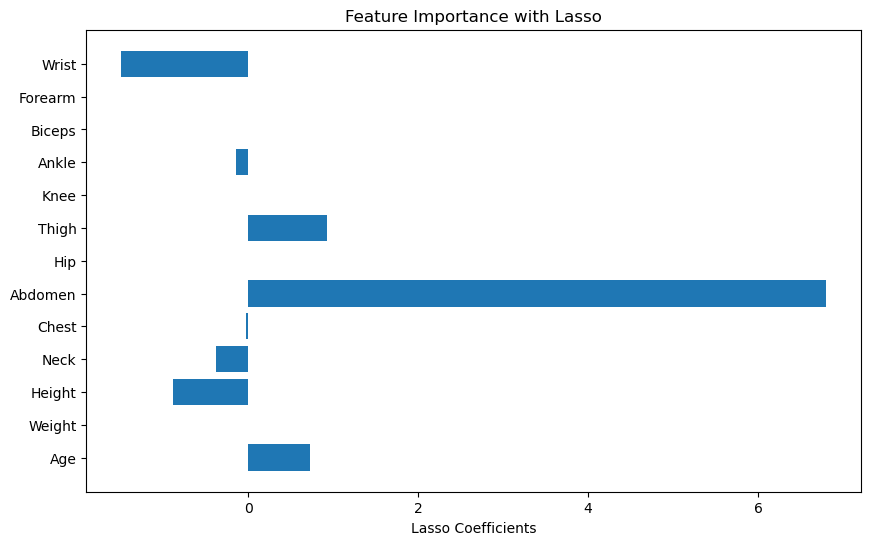


Optimal Features:
['Age', 'Height', 'Neck', 'Chest', 'Abdomen', 'Thigh', 'Knee', 'Ankle', 'Wrist']


In [40]:
## Using optimal alpha = 0.1
Lasso_Regression = Lasso(alpha = 0.1)
Lasso_Regression.fit(X_train_scaled, y_train)

## Showing features with their coefficients
coefficients = Lasso_Regression.coef_

for feature, coef in zip(X.columns, coefficients):
    print(f"{feature}: {coef:.3f}")

## Barplot to visualise variables with its coefficients
plt.figure(figsize=(10, 6))
plt.barh(X.columns, coefficients)
plt.xlabel("Lasso Coefficients")
plt.title("Feature Importance with Lasso")
plt.show()

optimal_features = [feature for feature, coef in zip(X.columns, coefficients) if coef != 0]
print("\nOptimal Features:")
print(optimal_features)

Moving forward, the dataset will be reduced to the optimal features

In [41]:
## Create new dataset with only the optimal features
X_train_optimal = X_train[optimal_features]
X_test_optimal = X_test[optimal_features]

In [42]:
## Standardise for Linear, Lasso and Ridge
X_train_scaled_optimal = ss.fit_transform(X_train_optimal)     ## Use X_train_optimal & X_test_optimal for Decision Tree and Random Forest
X_test_scaled_optimal = ss.transform(X_test_optimal)

### Lasso Regression

In [43]:
## Using previous optimal alpha = 0.1
Lasso_Regression = Lasso(alpha = 0.1)
Lasso_Regression.fit(X_train_scaled_optimal, y_train)
ylasso_pred = Lasso_Regression.predict(X_test_scaled_optimal)

In [44]:
## Calculating evaluation metrics for Lasso Regression
lassoMSE = mean_squared_error(y_test, ylasso_pred)
lassoRMSE = np.sqrt(lassoMSE)
lassoMAE = mean_absolute_error(y_test, ylasso_pred)
lassoR2 = r2_score(y_test, ylasso_pred)

print(f"Lasso Regression MSE: {lassoMSE:.3f}")
print(f"Lasso Regression RMSE: {lassoRMSE:.3f}")
print(f"Lasso Regression MAE: {lassoMAE:.3f}")
print(f"Lasso Regression R-Squared: {lassoR2:.3f}")

Lasso Regression MSE: 22.760
Lasso Regression RMSE: 4.771
Lasso Regression MAE: 4.012
Lasso Regression R-Squared: 0.611


### Linear Regression

In [45]:
Linear_Regression = LinearRegression()
Linear_Regression.fit(X_train_scaled_optimal, y_train)
ylinear_pred = Linear_Regression.predict(X_test_scaled_optimal)

In [46]:
## Calculating evaluation metrics for Linear Regression
linearMSE = mean_squared_error(y_test, ylinear_pred)
linearRMSE = np.sqrt(linearMSE)
linearMAE = mean_absolute_error(y_test, ylinear_pred)
linearR2 = r2_score(y_test, ylinear_pred)

print(f"Linear Regression MSE: {linearMSE:.3f}")
print(f"Linear Regression RMSE: {linearRMSE:.3f}")
print(f"Linear Regression MAE: {linearMAE:.3f}")
print(f"Linear Regression R-Squared: {linearR2:.3f}")

Linear Regression MSE: 23.261
Linear Regression RMSE: 4.823
Linear Regression MAE: 4.015
Linear Regression R-Squared: 0.603


### Ridge Regression

In [47]:
## Cross-validation to find optimal alpha
ridge_CV = Ridge()
ridge_param_grid = {'alpha': [0.1, 1, 10, 100, 1000]}
ridge_grid_search = GridSearchCV(ridge_CV, ridge_param_grid, cv = 10, scoring = 'neg_mean_squared_error')
ridge_grid_search.fit(X_train_scaled_optimal, y_train)
print(ridge_grid_search.best_params_)

{'alpha': 1}


In [48]:
## Using optimal alpha = 1.0
Ridge_Regression = Ridge(alpha = 1.0)
Ridge_Regression.fit(X_train_scaled_optimal, y_train)
yridge_pred = Ridge_Regression.predict(X_test_scaled_optimal)

In [49]:
## Calculating evaluation metrics for Ridge Regression
ridgeMSE = mean_squared_error(y_test, yridge_pred)
ridgeRMSE = np.sqrt(ridgeMSE)
ridgeMAE = mean_absolute_error(y_test, yridge_pred)
ridgeR2 = r2_score(y_test, yridge_pred)

print(f"Ridge Regression MSE: {ridgeMSE:.3f}")
print(f"Ridge Regression RMSE: {ridgeRMSE:.3f}")
print(f"Ridge Regression MAE: {ridgeMAE:.3f}")
print(f"Ridge Regression R-Squared: {ridgeR2:.3f}")

Ridge Regression MSE: 23.197
Ridge Regression RMSE: 4.816
Ridge Regression MAE: 4.018
Ridge Regression R-Squared: 0.604


### Decision Tree Regressor

In [50]:
## Cross-validation to find optimal pre-pruning parameters
DT_CV = DecisionTreeRegressor(random_state = 42)
dt_param_grid = {'max_depth': [3, 5, 10, None],
                 'min_samples_split': [2, 5, 10],
                 'min_samples_leaf': [1, 2, 5]
                }
dt_grid_search = GridSearchCV(DT_CV, dt_param_grid, cv = 10, scoring = 'neg_mean_squared_error')
dt_grid_search.fit(X_train_optimal, y_train)
print(dt_grid_search.best_params_)

{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [51]:
## Using optimal parameters
Decision_Tree = dt_grid_search.best_estimator_
ydecisiontree_pred = Decision_Tree.predict(X_test_optimal)

In [52]:
## Calculating evaluation metrics for Decision Tree Regressor
decisiontreeMSE = mean_squared_error(y_test, ydecisiontree_pred)
decisiontreeRMSE = np.sqrt(decisiontreeMSE)
decisiontreeMAE = mean_absolute_error(y_test, ydecisiontree_pred)
decisiontreeR2 = r2_score(y_test, ydecisiontree_pred)

print(f"Decision Tree MSE: {decisiontreeMSE:.3f}")
print(f"Decision Tree RMSE: {decisiontreeRMSE:.3f}")
print(f"Decision Tree MAE: {decisiontreeMAE:.3f}")
print(f"Decision Tree R-Squared: {decisiontreeR2:.3f}")

Decision Tree MSE: 42.858
Decision Tree RMSE: 6.547
Decision Tree MAE: 5.385
Decision Tree R-Squared: 0.268


In [53]:
## Checking if post-pruning is needed
ydt_train_pred = Decision_Tree.predict(X_train_optimal)
ydt_test_pred = Decision_Tree.predict(X_test_optimal)

## Compute MSE for training and test data
train_MSE = mean_squared_error(y_train, ydt_train_pred)
test_MSE = mean_squared_error(y_test, ydt_test_pred)

print(f"Training MSE: {train_MSE:.3f}")
print(f"Test RMSE: {test_MSE:.3f}")

Training MSE: 5.294
Test RMSE: 42.858


Since the training MSE is much lower than the test MSE, it suggest overfitting and thus post-pruning is needed.

In [54]:
## Post-pruning
pp_path = DT_CV.cost_complexity_pruning_path(X_train_optimal, y_train)
ccp_alphas, impurities = pp_path.ccp_alphas, pp_path.impurities

pruned_param_grid = {'ccp_alpha': ccp_alphas}
pruned_grid_search = GridSearchCV(DT_CV, pruned_param_grid, cv = 10, scoring = 'neg_mean_squared_error')
pruned_grid_search.fit(X_train_optimal, y_train)
print(pruned_grid_search.best_params_)

{'ccp_alpha': 1.480164980932301}


In [55]:
## Using optimal parameters for post-pruning
pruned_Decision_Tree = pruned_grid_search.best_estimator_
ydecisiontree_pred_pruned = pruned_Decision_Tree.predict(X_test_optimal)

In [56]:
## Calculating evaluation metrics for pruned Decision Tree Regressor
pruned_decisiontreeMSE = mean_squared_error(y_test, ydecisiontree_pred_pruned)
pruned_decisiontreeRMSE = np.sqrt(pruned_decisiontreeMSE)
pruned_decisiontreeMAE = mean_absolute_error(y_test, ydecisiontree_pred_pruned)
pruned_decisiontreeR2 = r2_score(y_test, ydecisiontree_pred_pruned)

print(f"Pruned Decision Tree MSE: {pruned_decisiontreeMSE:.3f}")
print(f"Pruned Decision Tree RMSE: {pruned_decisiontreeRMSE:.3f}")
print(f"Pruned Decision Tree MAE: {pruned_decisiontreeMAE:.3f}")
print(f"Pruned Decision Tree R-Squared: {pruned_decisiontreeR2:.3f}")

Pruned Decision Tree MSE: 29.928
Pruned Decision Tree RMSE: 5.471
Pruned Decision Tree MAE: 4.405
Pruned Decision Tree R-Squared: 0.489


It can be observed that after post-pruning, the RMSE decreased (6.55 to 5.47) and the R-Squared increased (0.27 to 0.49). Thus post-pruning played a significant role in improving model accuracy.

### Random Forest Regressor

In [57]:
## Cross-validation to find optimal parameters
RF_CV = RandomForestRegressor(random_state = 42)
rf_param_grid = {'n_estimators': [50, 100, 200, 500],
                 'max_features': ['sqrt', 'log2', None],
                 'max_depth': [3, 5, 10, None],
                 'min_samples_split': [2, 5, 10],
                 'min_samples_leaf': [1, 2, 5]
                }
rf_grid_search = GridSearchCV(RF_CV, rf_param_grid, cv = 10, scoring = 'neg_mean_squared_error')
rf_grid_search.fit(X_train_optimal, y_train)
print(rf_grid_search.best_params_)

{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


In [58]:
## Using the optimal parameters
Random_Forest = rf_grid_search.best_estimator_
yrandomforest_pred = Random_Forest.predict(X_test_optimal)

In [59]:
## Calculating evaluation metrics for Random Forest Regressor
randomforestMSE = mean_squared_error(y_test, yrandomforest_pred)
randomforestRMSE = np.sqrt(randomforestMSE)
randomforestMAE = mean_absolute_error(y_test, yrandomforest_pred)
randomforestR2 = r2_score(y_test, yrandomforest_pred)

print(f"Random Forest MSE: {randomforestMSE:.3f}")
print(f"Random Forest RMSE: {randomforestRMSE:.3f}")
print(f"Random Forest MAE: {randomforestMAE:.3f}")
print(f"Random Forest R-Squared: {randomforestR2:.3f}")

Random Forest MSE: 22.140
Random Forest RMSE: 4.705
Random Forest MAE: 3.914
Random Forest R-Squared: 0.622


Comparing all the model's tuned results, it can be seen that Lasso Regression had the best performance, demonstrating low RMSE and high R-Squared. This suggestst that Lasso Regression is the most accurate model amongst the ones used.

## Classification using Heart Failure Clinical Records

In [60]:
Xc = data_hfcr.drop(columns = ['DEATH_EVENT'])
yc = data_hfcr['DEATH_EVENT']

### Random Forest Classifier for Feature Selection

In [61]:
## Train-Test Split
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size = 0.3, random_state = 42)

In [62]:
## Hyperparameter Tuning
RC_CV = RandomForestClassifier(random_state = 42)
random_classifier_param_grid = {'n_estimators': [50, 100, 200, 500],
                                'max_features': ['sqrt', 'log2', None],
                                'max_depth': [3, 5, 10, None],
                                'min_samples_split': [2, 5, 10],
                                'min_samples_leaf': [1, 2, 5]
                               }

In [63]:
## Using the best parameters
randomclassifier_grid_search = GridSearchCV(RC_CV, random_classifier_param_grid, cv = 10, scoring = 'accuracy', n_jobs = -1)
randomclassifier_grid_search.fit(Xc_train, yc_train)
best_randomclassifier = randomclassifier_grid_search.best_estimator_

                     Feature  Importance
11                      time    0.423414
4          ejection_fraction    0.206132
7           serum_creatinine    0.144331
0                        age    0.069398
2   creatinine_phosphokinase    0.048587
8               serum_sodium    0.044802
6                  platelets    0.035483
1                    anaemia    0.015463
10                   smoking    0.003629
5        high_blood_pressure    0.003558
9                        sex    0.002603
3                   diabetes    0.002600


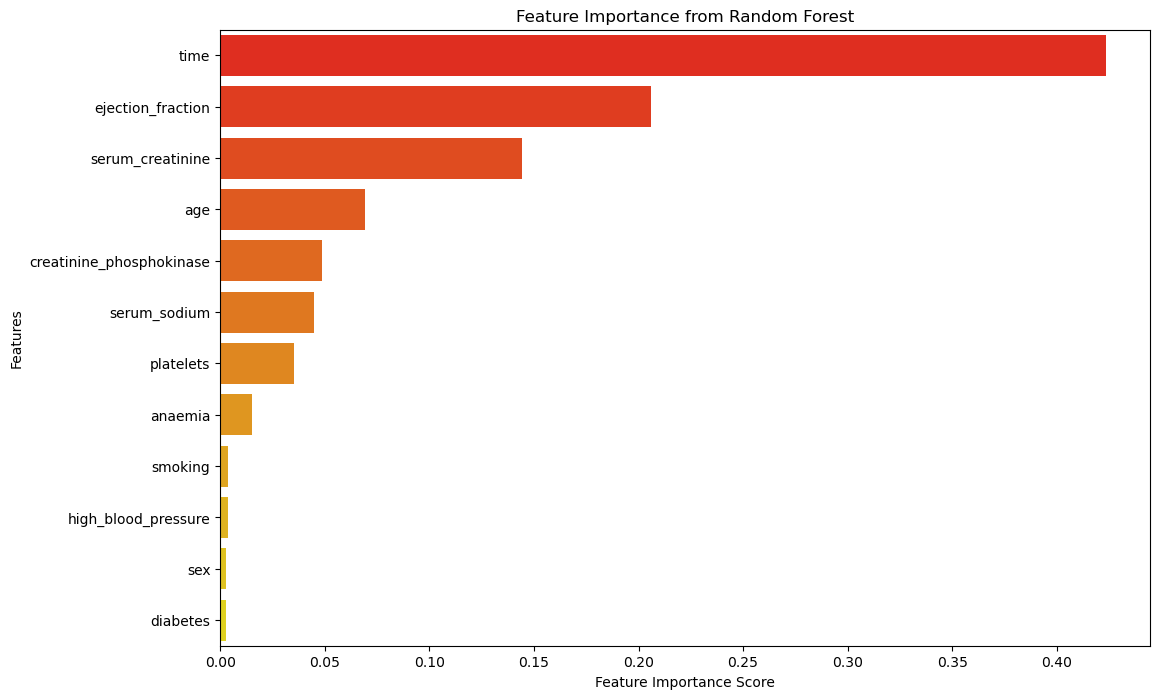

In [64]:
## Showing optimal features with their Importance Score from highest to lowest
random_optimal_features = pd.DataFrame({'Feature': Xc_train.columns, 'Importance': best_randomclassifier.feature_importances_})
random_optimal_features = random_optimal_features.sort_values(by = 'Importance', ascending = False)

print(random_optimal_features)

## Visualising variables and its importance score
plt.figure(figsize = (12,8))
sns.barplot(x = 'Importance', y = 'Feature', data = random_optimal_features, palette = 'autumn')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance from Random Forest")
plt.show()

In [65]:
## Selecting the top 4 optimal features
top_optimal = random_optimal_features.sort_values(by = 'Importance', ascending = False).head(4)['Feature'].tolist()

## Create new dataset with only the selected features
Xc_train_optimal = Xc_train[top_optimal]
Xc_test_optimal = Xc_test[top_optimal]

In [66]:
## Confirming class imbalance
yc_train.value_counts(normalize = True)

DEATH_EVENT
0    0.711538
1    0.288462
Name: proportion, dtype: float64

Since one class is significantly more frequent than the other, it indicates class imbalance. Thus, balanced accuracy score and F1 score will be used for evaluation.

### Random Forest Classifier

Random Forest Balanced Accuracy: 0.743
Random Forest F1 Score: 0.621


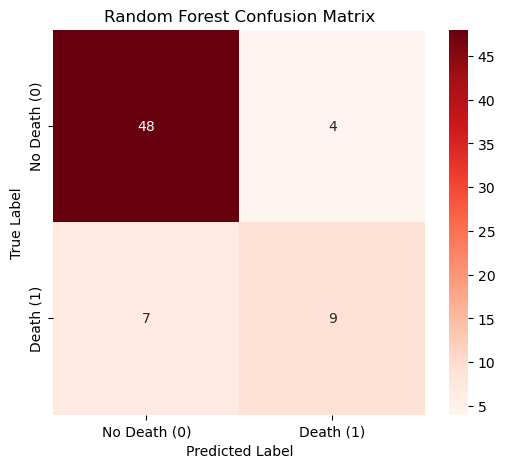

In [67]:
## Using previous optimal parameters
best_randomclassifier.fit(Xc_train_optimal, yc_train)

yrandomclassifier_pred = best_randomclassifier.predict(Xc_test_optimal)

## Convert yc_test and y(model)_prediction to integer type so that both variables match - applies to all following models
yc_test = yc_test.astype(int)
yrandomclassifier_pred = yrandomclassifier_pred.astype(int)

## Calculating evaluation metrics for Random Forest Classifier
RCbalancedaccuracy = balanced_accuracy_score(yc_test, yrandomclassifier_pred)
RCf1score = f1_score(yc_test, yrandomclassifier_pred)
RCconfusion_matrix = confusion_matrix(yc_test, yrandomclassifier_pred)

print(f"Random Forest Balanced Accuracy: {RCbalancedaccuracy:.3f}")
print(f"Random Forest F1 Score: {RCf1score:.3f}")

## Confusion Matrix for Random Forest Classifier
plt.figure(figsize = (6, 5))
sns.heatmap(RCconfusion_matrix, annot = True, fmt = 'd', cmap = 'Reds', xticklabels = ['No Death (0)', 'Death (1)'], yticklabels = ['No Death (0)', 'Death (1)'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Random Forest Confusion Matrix")
plt.show()

### Logistic Regression

In [68]:
## Scaling for Logistic Regression and KNN
Xc_train_scaled = Xc_train_optimal.copy()
Xc_test_scaled = Xc_test_optimal.copy()

Xc_train_scaled = ss.fit_transform(Xc_train_scaled)
Xc_test_scaled = ss.transform(Xc_test_scaled) 

In [69]:
## Hyperparameter tuning
### Since some penalties are incompatible with certain solvers, the parameter grid is split to ensure compatibility.

LR_CV = LogisticRegression()

logistic_param_grid_saga = {'penalty': ['elasticnet'],       ## Supports elasticnet for saga
                            'C': np.logspace(-4, 4, 20),
                            'solver': ['saga'],
                            'max_iter': [100, 1000, 2500, 5000],
                            'l1_ratio': [0, 0.1, 0.5, 0.9, 1]      ## Only needed for elasticnet
                           }

logistic_param_grid_lbfgs_newton_sag = {'penalty': ['l2'],        ## Only 'l2' 
                                        'C': np.logspace(-4, 4, 20),
                                        'solver': ['lbfgs', 'newton-cg', 'sag'],
                                        'max_iter': [100, 1000, 2500, 5000]
                                       }
                                       
logistic_param_grid_none = {'penalty': [None],          ## Only None
                            'solver': ['lbfgs', 'newton-cg', 'sag'],
                            'max_iter': [100, 1000, 2500, 5000]
                            }    

logistic_param_grid_liblinear = {'penalty': ['l1', 'l2'],       ## Only 'l1' and 'l2'
                                 'C': np.logspace(-4, 4, 20),
                                 'solver': ['liblinear'],
                                 'max_iter': [100, 1000, 2500, 5000]
                                }

In [70]:
## For saga solvers
logistic_grid_search_saga = GridSearchCV(LR_CV, logistic_param_grid_saga, cv = 10, scoring = 'accuracy', n_jobs = -1)

## For lbfgs, newton-cg and sag solvers
logistic_grid_search_lbfgs_newton_sag = GridSearchCV(LR_CV, logistic_param_grid_lbfgs_newton_sag, cv = 10, scoring = 'accuracy', n_jobs = -1)

## For None penalty
logistic_grid_search_none = GridSearchCV(LR_CV, logistic_param_grid_none, cv = 10, scoring = 'accuracy', n_jobs = -1)

## For liblinear solvers
logistic_grid_search_liblinear = GridSearchCV(LR_CV, logistic_param_grid_liblinear, cv = 10, scoring = 'accuracy', n_jobs = -1)

In [71]:
## For saga solvers
logistic_grid_search_saga.fit(Xc_train_scaled, yc_train)

## For lbfgs, newton-cg and sag solvers
logistic_grid_search_lbfgs_newton_sag.fit(Xc_train_scaled, yc_train)

## For None penalty
logistic_grid_search_none.fit(Xc_train_scaled, yc_train)

## For liblinear solvers
logistic_grid_search_liblinear.fit(Xc_train_scaled, yc_train)

## Using the respective optimal parameters
best_logistic_model_saga = logistic_grid_search_saga.best_estimator_
best_logistic_model_lbfgs_newton_sag = logistic_grid_search_lbfgs_newton_sag.best_estimator_
best_logistic_model_none = logistic_grid_search_none.best_estimator_
best_logistic_model_liblinear = logistic_grid_search_liblinear.best_estimator_

In [72]:
## Prediction
ysaga_pred = best_logistic_model_saga.predict(Xc_test_scaled)
ylbfgsnewtonsag_pred = best_logistic_model_lbfgs_newton_sag.predict(Xc_test_scaled)
ynone_pred = best_logistic_model_none.predict(Xc_test_scaled)
yliblinear_pred = best_logistic_model_liblinear.predict(Xc_test_scaled)

In [73]:
ysaga_pred = ysaga_pred.astype(int)

## Calculating evaluation metrics for Logistic Regression (saga)
sagabalancedaccuracy = balanced_accuracy_score(yc_test, ysaga_pred)
sagaf1score = f1_score(yc_test, ysaga_pred)
sagaconfusion_matrix = confusion_matrix(yc_test, ysaga_pred)

print(f"saga Balanced Accuracy: {sagabalancedaccuracy:.3f}")
print(f"saga F1 Score: {sagaf1score:.3f}")
print(f"saga Confusion Matrix: {sagaconfusion_matrix}")

saga Balanced Accuracy: 0.606
saga F1 Score: 0.364
saga Confusion Matrix: [[50  2]
 [12  4]]


In [74]:
ylbfgsnewtonsag_pred = ylbfgsnewtonsag_pred.astype(int)

## Calculating evaluation metrics for Logistic Regression (newton)
lbfgsnewtonsagbalancedaccuracy = balanced_accuracy_score(yc_test, ylbfgsnewtonsag_pred)
lbfgsnewtonsagf1score = f1_score(yc_test, ylbfgsnewtonsag_pred)
lbfgsnewtonsagconfusion_matrix = confusion_matrix(yc_test, ylbfgsnewtonsag_pred)

print(f"lbfgsnewtonsag Balanced Accuracy: {lbfgsnewtonsagbalancedaccuracy:.3f}")
print(f"lbfgsnewtonsag F1 Score: {lbfgsnewtonsagf1score:.3f}")
print(f"lbfgsnewtonsag Confusion Matrix: {lbfgsnewtonsagconfusion_matrix}")

lbfgsnewtonsag Balanced Accuracy: 0.680
lbfgsnewtonsag F1 Score: 0.519
lbfgsnewtonsag Confusion Matrix: [[48  4]
 [ 9  7]]


In [75]:
ynone_pred = ynone_pred.astype(int)

## Calculating evaluation metrics for Logistic Regression (none)
nonebalancedaccuracy = balanced_accuracy_score(yc_test, ynone_pred)
nonef1score = f1_score(yc_test, ynone_pred)
noneconfusion_matrix = confusion_matrix(yc_test, ynone_pred)

print(f"none Balanced Accuracy: {nonebalancedaccuracy:.3f}")
print(f"none F1 Score: {nonef1score:.3f}")
print(f"none Confusion Matrix: {noneconfusion_matrix}")

none Balanced Accuracy: 0.712
none F1 Score: 0.571
none Confusion Matrix: [[48  4]
 [ 8  8]]


In [76]:
yliblinear_pred = yliblinear_pred.astype(int)

## Calculating evaluation metrics for Logistic Regression (liblinear)
libbalancedaccuracy = balanced_accuracy_score(yc_test, yliblinear_pred)
libf1score = f1_score(yc_test, yliblinear_pred)
libconfusion_matrix = confusion_matrix(yc_test, yliblinear_pred)

print(f"liblinear Balanced Accuracy: {libbalancedaccuracy:.3f}")
print(f"liblinear F1 Score: {libf1score:.3f}")
print(f"liblinear Confusion Matrix: {libconfusion_matrix}")

liblinear Balanced Accuracy: 0.774
liblinear F1 Score: 0.667
liblinear Confusion Matrix: [[48  4]
 [ 6 10]]


Comparing the results between parameters, it can be observed that the solver 'liblinear' with its penalty 'l1' and 'l2' had the best result.

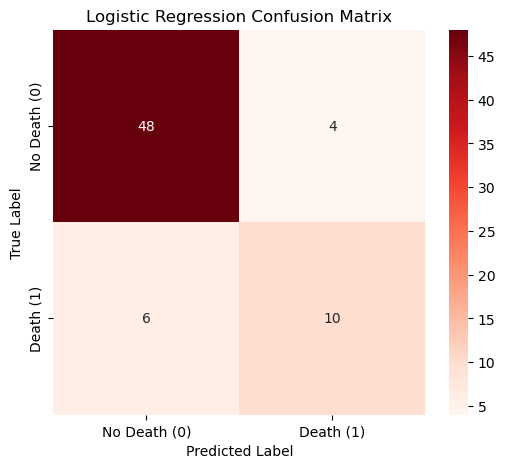

In [77]:
## Only showing Confusion Matrix for the best scores for Logistic Regression - liblinear
plt.figure(figsize = (6, 5))
sns.heatmap(libconfusion_matrix, annot = True, fmt = 'd', cmap = 'Reds', xticklabels = ['No Death (0)', 'Death (1)'], yticklabels = ['No Death (0)', 'Death (1)'])         
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

### K-Nearest Neighbours

In [78]:
## Hyperparameter tuning
knn_CV = KNeighborsClassifier()
knn_param_grid = {'n_neighbors': [3, 5, 7, 9, 11],
                  'weights': ['uniform', 'distance'],
                  'metric': ['euclidean', 'manhattan'],
                  'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
                 }

In [79]:
## Using the optimal parameters
knn_grid_search = GridSearchCV(knn_CV, knn_param_grid, cv = 10, scoring = 'accuracy', n_jobs = -1)
knn_grid_search.fit(Xc_train_scaled, yc_train)
KNN = knn_grid_search.best_estimator_

KNN Balanced Accuracy: 0.721
KNN F1 Score: 0.593


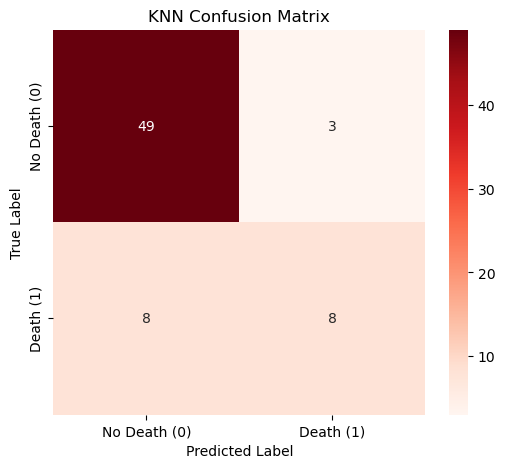

In [80]:
yknn_pred = KNN.predict(Xc_test_scaled)
yknn_pred = yknn_pred.astype(int)

## Calculating evaluation metrics for KNN
KNNbalancedaccuracy = balanced_accuracy_score(yc_test, yknn_pred)
KNNf1score = f1_score(yc_test, yknn_pred)
KNNconfusion_matrix = confusion_matrix(yc_test, yknn_pred)

print(f"KNN Balanced Accuracy: {KNNbalancedaccuracy:.3f}")
print(f"KNN F1 Score: {KNNf1score:.3f}")

## Confusion Matrix for KNN
plt.figure(figsize = (6, 5))
sns.heatmap(KNNconfusion_matrix, annot = True, fmt = 'd', cmap = 'Reds', xticklabels = ['No Death (0)', 'Death (1)'], yticklabels = ['No Death (0)', 'Death (1)'])    
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("KNN Confusion Matrix")
plt.show()

### Decision Tree Classifier

In [81]:
## Cross-validation to find optimal pre-pruning parameters
DC_CV = DecisionTreeClassifier(random_state = 42)
decision_classifier_param_grid = {'max_depth': [3, 5, 10, None],
                                  'min_samples_split': [2, 5, 10],
                                  'min_samples_leaf': [1, 2, 5]
                                 }

In [82]:
## Using the optimal parameters
decisionclassifier_grid_search = GridSearchCV(DC_CV, decision_classifier_param_grid, cv = 10, scoring = 'accuracy', n_jobs = -1)
decisionclassifier_grid_search.fit(Xc_train_optimal, yc_train)
decisionclassifier = decisionclassifier_grid_search.best_estimator_

Decision Tree Balanced Accuracy: 0.764
Decision Tree F1 Score: 0.645


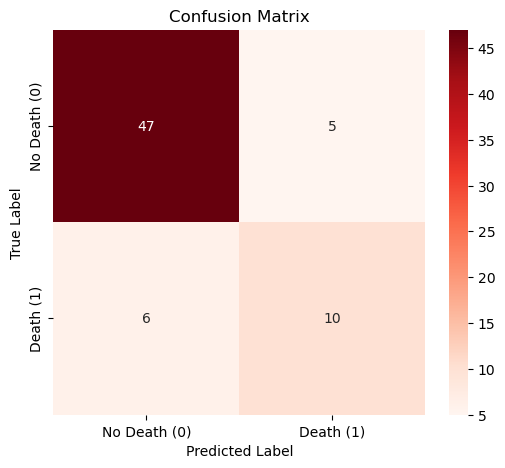

In [83]:
ydecisionclassifier_pred = decisionclassifier.predict(Xc_test_optimal)
ydecisionclassifier_pred = ydecisionclassifier_pred.astype(int)

## Calculating evaluation metrics for Decision Tree Classifier
DCbalancedaccuracy = balanced_accuracy_score(yc_test, ydecisionclassifier_pred)
DCf1score = f1_score(yc_test, ydecisionclassifier_pred)
DCconfusion_matrix = confusion_matrix(yc_test, ydecisionclassifier_pred)

print(f"Decision Tree Balanced Accuracy: {DCbalancedaccuracy:.3f}")
print(f"Decision Tree F1 Score: {DCf1score:.3f}")

## Confusion Matrix for Decision Tree Classifier
plt.figure(figsize = (6, 5))
sns.heatmap(DCconfusion_matrix, annot = True, fmt = 'd', cmap = 'Reds', xticklabels = ['No Death (0)', 'Death (1)'], yticklabels = ['No Death (0)', 'Death (1)'])    
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [84]:
## Checking if post-pruning is needed
train_balancedaccuracy = balanced_accuracy_score(yc_train, decisionclassifier.predict(Xc_train_optimal))
test_balancedaccuracy = balanced_accuracy_score(yc_test, ydecisionclassifier_pred)

print(f"Training Accuracy: {train_balancedaccuracy:.3f}")
print(f"Test Accuracy: {test_balancedaccuracy:.3f}")

Training Accuracy: 0.938
Test Accuracy: 0.764


Since the training accuracy is higher than the test accuracy, it may suggest that the decision tree classifier is overfitting. Thus, post-pruning is done.

In [85]:
## Post-pruning
classifier_path = DC_CV.cost_complexity_pruning_path(Xc_train_optimal, yc_train)
ccp_alphas, impurities = classifier_path.ccp_alphas, classifier_path.impurities

classifier_prune_param_grid = {'ccp_alpha': ccp_alphas[:-1]}
classifier_prune_grid_search = GridSearchCV(DC_CV, classifier_prune_param_grid, cv = 10, scoring = 'accuracy', n_jobs = -1)
classifier_prune_grid_search.fit(Xc_train_optimal, yc_train)
print(classifier_prune_grid_search.best_params_)

{'ccp_alpha': 0.037996294939062425}


In [86]:
## Using best ccp_alpha 
pruned_decisionclassifier = classifier_prune_grid_search.best_estimator_
ydecisionclassifer_pred_pruned = pruned_decisionclassifier.predict(Xc_test_optimal)

Pruned Decision Tree Balanced Accuracy: 0.743
Pruned Decision Tree F1 Score: 0.621


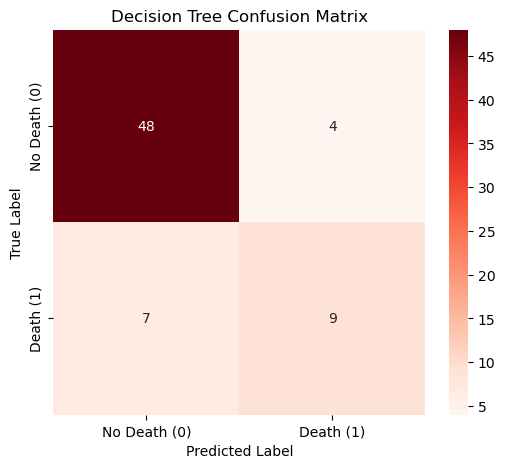

In [87]:
ydecisionclassifer_pred_pruned = ydecisionclassifer_pred_pruned.astype(int)

## Calculating evaluation metrics for pruned Decision Tree Classifier
pruned_DCbalancedaccuracy = balanced_accuracy_score(yc_test, ydecisionclassifer_pred_pruned)
pruned_DCf1score = f1_score(yc_test, ydecisionclassifer_pred_pruned)
pruned_DCconfusion_matrix = confusion_matrix(yc_test, ydecisionclassifer_pred_pruned)

print(f"Pruned Decision Tree Balanced Accuracy: {pruned_DCbalancedaccuracy:.3f}")
print(f"Pruned Decision Tree F1 Score: {pruned_DCf1score:.3f}")

## Confusion Matrix for pruned Decision Tree Classifier
plt.figure(figsize = (6, 5))
sns.heatmap(pruned_DCconfusion_matrix, annot = True, fmt = 'd', cmap = 'Reds', xticklabels = ['No Death (0)', 'Death (1)'], yticklabels = ['No Death (0)', 'Death (1)'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree Confusion Matrix")
plt.show()

It can be seen that the balanced accuracy has dropped from 0.764 to 0.743 and the f1-score has also dropped from 0.645 to 0.621. This suggests that post-pruning simplified the model at the cost of its predictive performance.

Comparing all the model's tuned results, it can be seen that Logistic Regression had the best performance, demonstrating the highest balanced accuracy and f1-score. Its confusion matrix also had the highest output for True Negatives and Positives. This suggestst that Logistic Regression is the most accurate model amongst the ones used.